# Spain Power System — AC OPF Results

Reads the CSV files saved by `run_opf.jl` from the `results/` directory and produces:
- OPF summary statistics
- Fuel-mix dispatch bar chart
- Installed capacity vs. dispatch comparison
- Generator dispatch scatter (capacity vs. dispatch, coloured by fuel)
- Reactive power procurement by fuel and P–Q operating points
- Bus voltage magnitude distribution
- Reactive branch flow analysis
- Branch loading distribution
- Congested branches

**Run `julia run_opf.jl` first** to generate the result files.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RESULTS = Path('results')

FUEL_COLORS = {
    'Wind':                '#4CAF50',
    'Solar':               '#FFC107',
    'Hydro':               '#2196F3',
    'Nuclear':             '#9C27B0',
    'Gas':                 '#F44336',
    'Coal':                '#212121',
    'Biomass':             '#795548',
    'Oil':                 '#607D8B',
    'Electricity Storage': '#00BCD4',
    'Slack':               '#BDBDBD',
}

In [41]:
# Load result CSVs
def load_results():
    missing = [f for f in ['summary.csv', 'gen_dispatch.csv', 'fuel_mix.csv', 'branch_flows.csv']
               if not (RESULTS / f).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing result files: {missing}\n"
            "Run  julia run_opf.jl  first to generate them."
        )
    return (
        pd.read_csv(RESULTS / 'summary.csv'),
        pd.read_csv(RESULTS / 'gen_dispatch.csv'),
        pd.read_csv(RESULTS / 'fuel_mix.csv'),
        pd.read_csv(RESULTS / 'branch_flows.csv'),
    )

summary_df, gen_df, fuel_df, branch_df = load_results()
print('Result files loaded successfully.')

Result files loaded successfully.


## Summary

In [42]:
n_hours = summary_df[['date', 'hour']].drop_duplicates().shape[0]
solved_mask = summary_df['status'].isin(['OPTIMAL', 'LOCALLY_SOLVED'])
print(f"{'='*55}")
print(f"AC OPF Summary — {len(summary_df['date'].unique())} days, {n_hours} hourly snapshots")
print(f"{'='*55}")

for date, grp in summary_df.groupby('date'):
    solved = grp[solved_mask & (grp['date'] == date)]
    label  = pd.Timestamp(date).strftime('%d %B %Y')
    cong_per_hour = (branch_df[branch_df['date'] == date]
                     .groupby('hour')
                     .apply(lambda x: (x['loading_pct'] > 90).sum()))
    print(f"\n  {label}")
    print(f"    Hours solved     : {len(solved)} / {len(grp)}")
    print(f"    Avg system cost  : {solved['objective_eur_h'].mean():>13,.0f} €/h")
    print(f"    Load range       : {solved['total_load_mw'].min():>7,.0f} – "
          f"{solved['total_load_mw'].max():,.0f} MW")
    print(f"    Avg generation   : {solved['total_gen_mw'].mean():>13,.1f} MW")
    print(f"    Congested lines  : avg {cong_per_hour.mean():.0f}, "
          f"max {cong_per_hour.max():.0f} per hour  (>90% apparent loading)")

print(f"\n{'='*55}")

AC OPF Summary — 2 days, 48 hourly snapshots

  08 July 2024
    Hours solved     : 24 / 24
    Avg system cost  :       123,870 €/h
    Load range       :  21,316 – 39,965 MW
    Avg generation   :      31,363.6 MW
    Congested lines  : avg 3, max 8 per hour  (>90% apparent loading)

  02 December 2024
    Hours solved     : 24 / 24
    Avg system cost  :       504,308 €/h
    Load range       :  21,233 – 33,884 MW
    Avg generation   :      29,527.0 MW
    Congested lines  : avg 2, max 3 per hour  (>90% apparent loading)



## Fuel Mix Dispatch

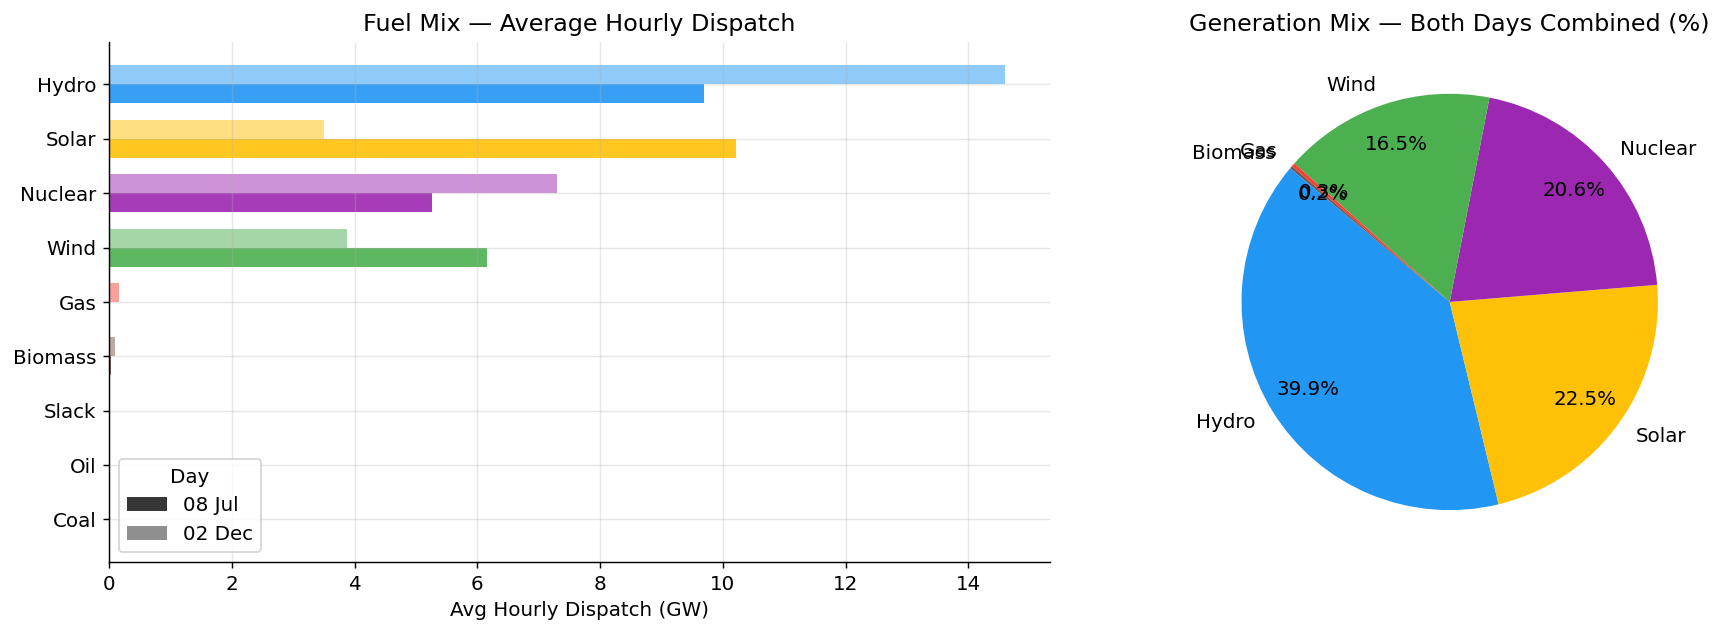

In [43]:
# Average hourly dispatch per fuel, per day
avg_fuel = (fuel_df.groupby(['date', 'fuel'])['dispatch_mw']
            .mean().reset_index())

days     = sorted(avg_fuel['date'].unique())
fuel_ord = (avg_fuel.groupby('fuel')['dispatch_mw'].sum()
            .sort_values(ascending=True).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: grouped horizontal bars — one shade per day, fuel colours
x, w = np.arange(len(fuel_ord)), 0.35
for i, day in enumerate(days):
    vals = [avg_fuel[(avg_fuel['date'] == day) & (avg_fuel['fuel'] == f)]['dispatch_mw'].sum() / 1e3
            for f in fuel_ord]
    axes[0].barh(x + (i - 0.5) * w, vals, w,
                 color=[FUEL_COLORS.get(f, '#90A4AE') for f in fuel_ord],
                 alpha=0.9 if i == 0 else 0.5,
                 label=pd.Timestamp(day).strftime('%d %b'))

axes[0].set_yticks(x)
axes[0].set_yticklabels(fuel_ord)
axes[0].set_xlabel('Avg Hourly Dispatch (GW)')
axes[0].set_title('Fuel Mix — Average Hourly Dispatch')
axes[0].legend(title='Day')

# Right: pie — total across all hours and both days
total = (fuel_df.groupby('fuel')['dispatch_mw'].sum()
         .reset_index().query('dispatch_mw > 1')
         .sort_values('dispatch_mw', ascending=False))
axes[1].pie(total['dispatch_mw'],
            labels=total['fuel'],
            colors=[FUEL_COLORS.get(f, '#90A4AE') for f in total['fuel']],
            autopct='%1.1f%%', startangle=140, pctdistance=0.8)
axes[1].set_title('Generation Mix — Both Days Combined (%)')

plt.tight_layout()
plt.savefig(RESULTS / 'fuel_mix.png', bbox_inches='tight')
plt.show()

## Installed Capacity vs. Dispatch

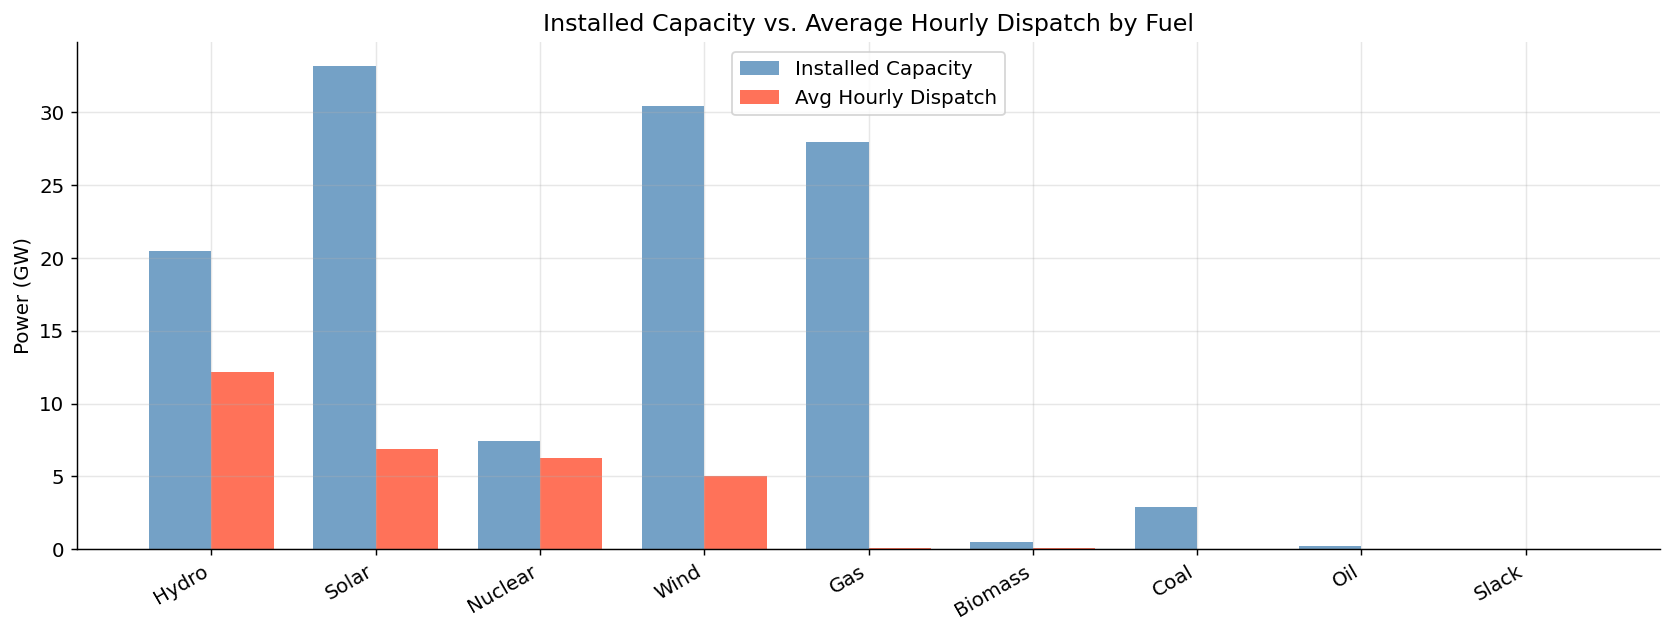

In [61]:
# Average dispatch per fuel across all hours and both days
avg_fuel_all = (fuel_df.groupby('fuel')
                .agg(dispatch_mw=('dispatch_mw', 'mean'),
                     capacity_mw=('capacity_mw', 'first'))
                .reset_index()
                .sort_values('dispatch_mw', ascending=False))
avg_fuel_all = avg_fuel_all[avg_fuel_all['capacity_mw'] > 1].copy()

# Hide installed capacity for Slack bus as it is artificially large
avg_fuel_all.loc[avg_fuel_all['fuel'] == 'Slack', 'capacity_mw'] = np.nan

x, width = np.arange(len(avg_fuel_all)), 0.38

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, avg_fuel_all['capacity_mw'] / 1e3, width,
       label='Installed Capacity', color='steelblue', alpha=0.75)
ax.bar(x + width/2, avg_fuel_all['dispatch_mw'] / 1e3, width,
       label='Avg Hourly Dispatch', color='tomato', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(avg_fuel_all['fuel'], rotation=30, ha='right')
ax.set_ylabel('Power (GW)')
ax.set_title('Installed Capacity vs. Average Hourly Dispatch by Fuel')
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / 'capacity_vs_dispatch.png', bbox_inches='tight')
plt.show()

## Top Dispatched Generators

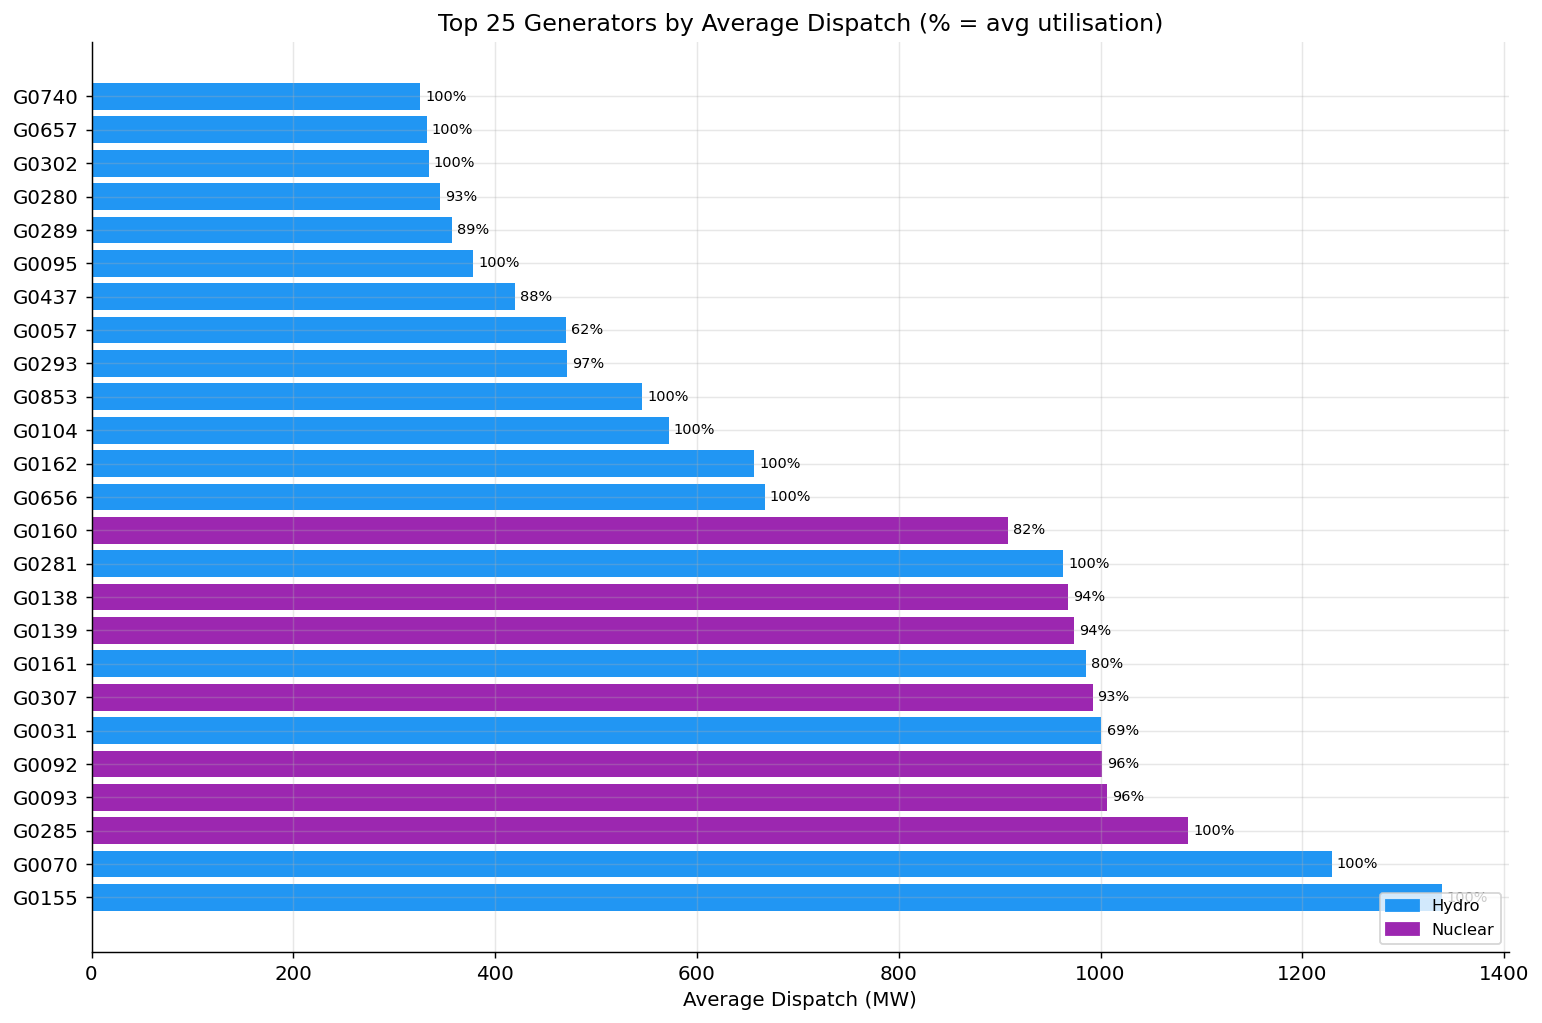

In [45]:
top_n   = 25
avg_gen = (gen_df[gen_df['dispatch_mw'] > 0.5]
           .groupby(['unit_name', 'fuel', 'capacity_mw'])
           .agg(dispatch_mw=('dispatch_mw', 'mean'),
                utilization_pct=('utilization_pct', 'mean'))
           .reset_index()
           .sort_values('dispatch_mw', ascending=False)
           .head(top_n))
colors = [FUEL_COLORS.get(f, '#90A4AE') for f in avg_gen['fuel']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(avg_gen['unit_name'], avg_gen['dispatch_mw'], color=colors)

for bar, util in zip(bars, avg_gen['utilization_pct']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{util:.0f}%", va='center', fontsize=8)

ax.set_xlabel('Average Dispatch (MW)')
ax.set_title(f'Top {top_n} Generators by Average Dispatch (% = avg utilisation)')

shown = avg_gen['fuel'].unique()
legend_patches = [mpatches.Patch(color=FUEL_COLORS.get(f, '#90A4AE'), label=f) for f in shown]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / 'top_generators.png', bbox_inches='tight')
plt.show()

## Generator Capacity vs. Dispatch Scatter

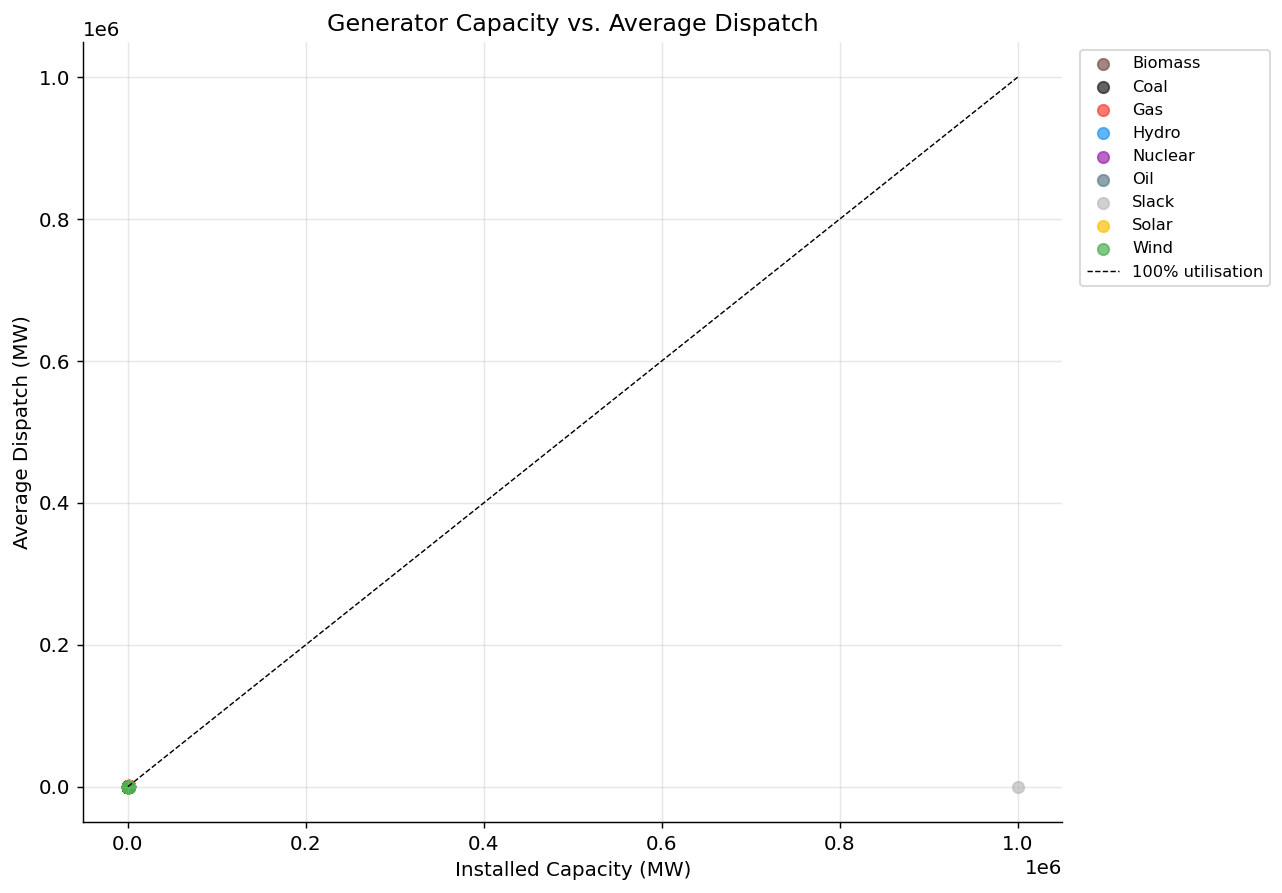

In [ ]:
# Average dispatch per generator across all hours and both days
avg_gen_scatter = (gen_df[(gen_df['capacity_mw'] > 0) & (gen_df['fuel'] != 'Slack')]
                   .groupby(['unit_name', 'fuel', 'capacity_mw'])
                   ['dispatch_mw'].mean()
                   .reset_index())

fig, ax = plt.subplots(figsize=(10, 7))
for fuel, grp in avg_gen_scatter.groupby('fuel'):
    ax.scatter(grp['capacity_mw'], grp['dispatch_mw'],
               color=FUEL_COLORS.get(fuel, '#90A4AE'),
               alpha=0.7, s=40, label=fuel)

max_cap = avg_gen_scatter['capacity_mw'].max()
ax.plot([0, max_cap], [0, max_cap], 'k--', linewidth=0.8, label='100% utilisation')

ax.set_xlabel('Installed Capacity (MW)')
ax.set_ylabel('Average Dispatch (MW)')
ax.set_title('Generator Capacity vs. Average Dispatch')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / 'gen_scatter.png', bbox_inches='tight')
plt.show()

## Branch Loading

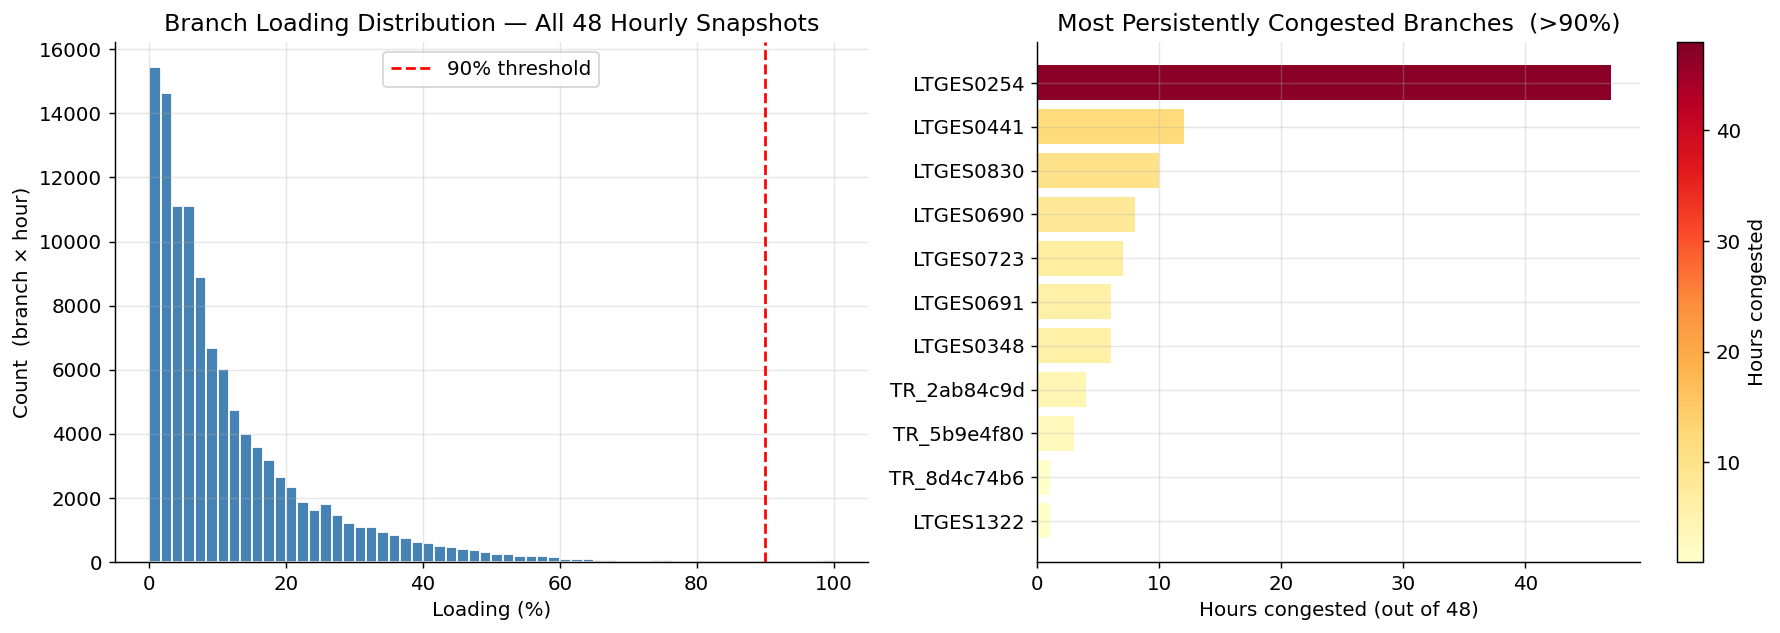

In [47]:
n_snapshots = branch_df[['date', 'hour']].drop_duplicates().shape[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram across all (branch × hour) entries
axes[0].hist(branch_df['loading_pct'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
axes[0].set_xlabel('Loading (%)')
axes[0].set_ylabel('Count  (branch × hour)')
axes[0].set_title(f'Branch Loading Distribution — All {n_snapshots} Hourly Snapshots')
axes[0].legend()

# Right: branches ranked by number of hours they exceed 90%
cong_summary = (branch_df[branch_df['loading_pct'] > 90]
                .groupby('branch_name')
                .agg(congested_hours=('loading_pct', 'count'),
                     max_loading=('loading_pct', 'max'))
                .reset_index()
                .sort_values('congested_hours', ascending=True)
                .tail(20))

if len(cong_summary) > 0:
    cmap = plt.cm.YlOrRd
    norm = plt.Normalize(1, n_snapshots)
    bar_colors = [cmap(norm(v)) for v in cong_summary['congested_hours']]
    axes[1].barh(cong_summary['branch_name'], cong_summary['congested_hours'],
                 color=bar_colors)
    axes[1].set_xlabel(f'Hours congested (out of {n_snapshots})')
    axes[1].set_title('Most Persistently Congested Branches  (>90%)')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=axes[1], label='Hours congested')
else:
    axes[1].text(0.5, 0.5, 'No congested branches\n(all below 90%)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Congested Branches')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'branch_loading.png', bbox_inches='tight')
plt.show()

## Reactive Power Procurement

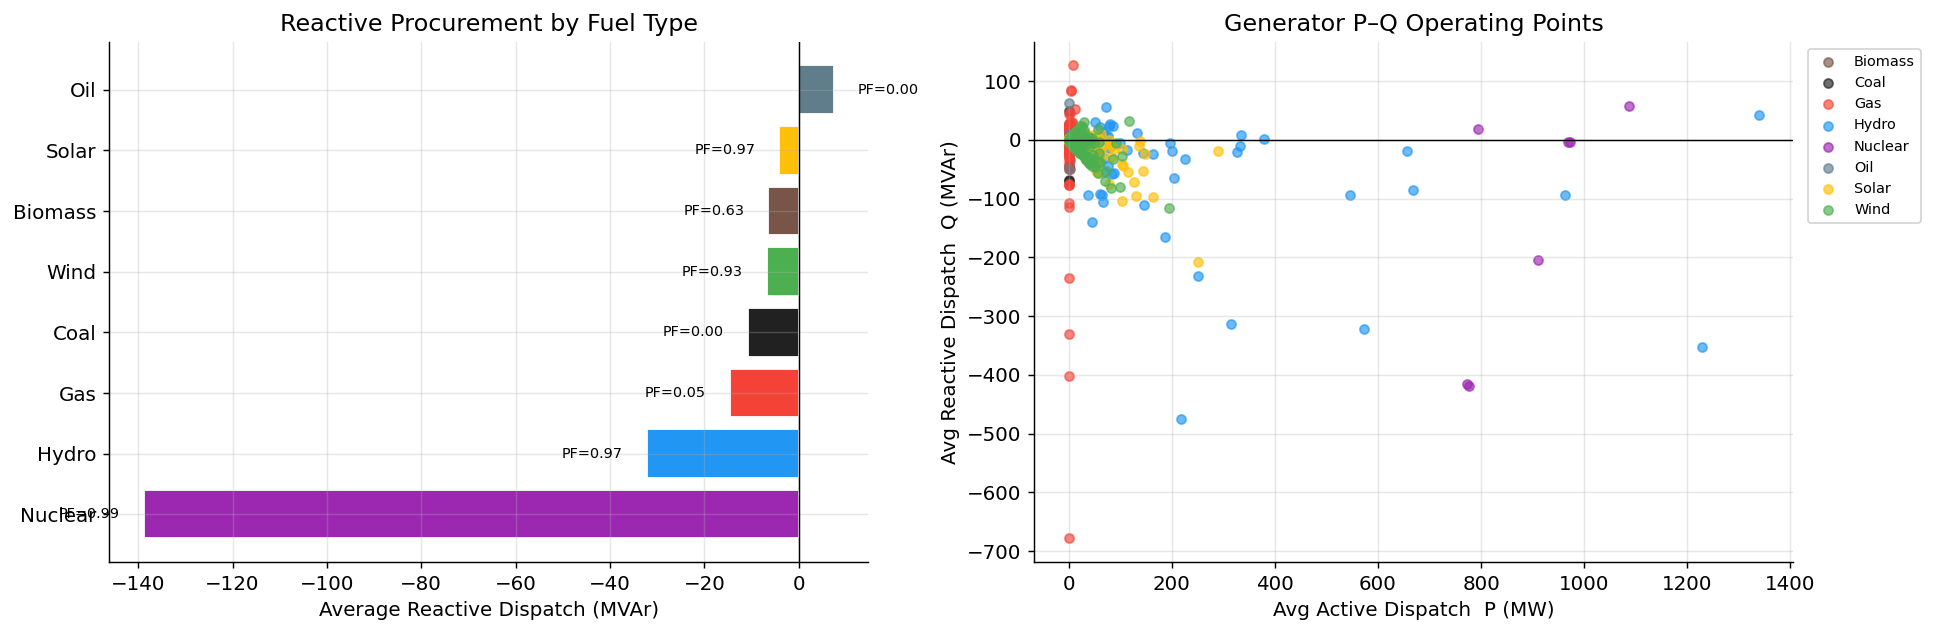

In [48]:
gen_ac = gen_df[gen_df['fuel'] != 'Slack'].copy()

avg_q = (gen_ac.groupby('fuel')
         .agg(q_mvar=('dispatch_mvar', 'mean'),
              p_mw=('dispatch_mw', 'mean'))
         .reset_index()
         .sort_values('q_mvar'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: average reactive dispatch by fuel
colors = [FUEL_COLORS.get(f, '#90A4AE') for f in avg_q['fuel']]
axes[0].barh(avg_q['fuel'], avg_q['q_mvar'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Average Reactive Dispatch (MVAr)')
axes[0].set_title('Reactive Procurement by Fuel Type')
for i, (q, p) in enumerate(zip(avg_q['q_mvar'], avg_q['p_mw'])):
    pf_str = f"PF={p/np.hypot(p,q):.2f}" if np.hypot(p,q) > 0 else ""
    axes[0].text(q + (5 if q >= 0 else -5), i, pf_str,
                 va='center', ha='left' if q >= 0 else 'right', fontsize=8)

# Right: P–Q operating points per generator
for fuel, grp in gen_ac.groupby('fuel'):
    pq = grp.groupby('unit_name')[['dispatch_mw', 'dispatch_mvar']].mean()
    axes[1].scatter(pq['dispatch_mw'], pq['dispatch_mvar'],
                    color=FUEL_COLORS.get(fuel, '#90A4AE'),
                    alpha=0.65, s=25, label=fuel)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Avg Active Dispatch  P (MW)')
axes[1].set_ylabel('Avg Reactive Dispatch  Q (MVAr)')
axes[1].set_title('Generator P–Q Operating Points')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'reactive_procurement.png', bbox_inches='tight')
plt.show()

## Bus Voltage Profile

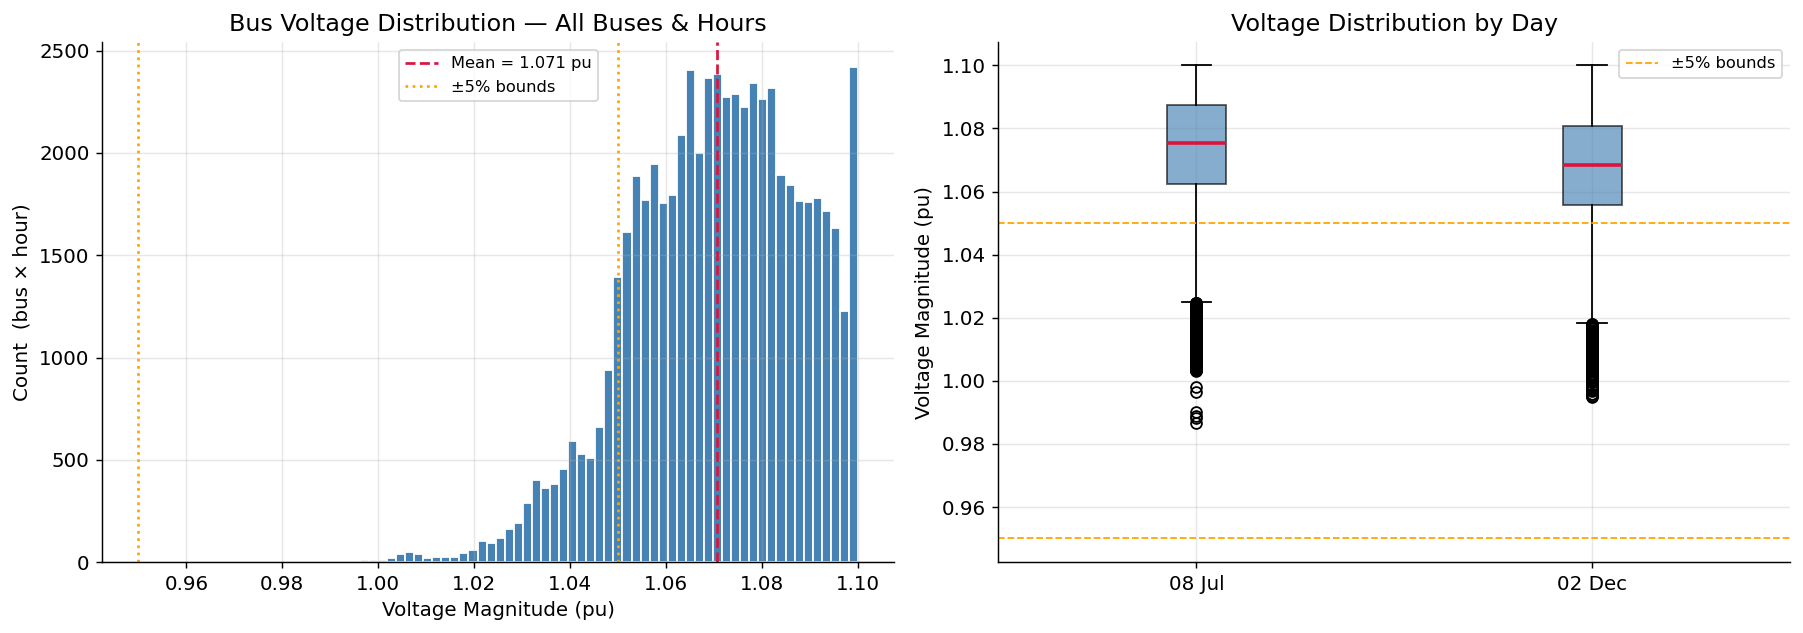


Voltage statistics (all buses × all hours):
  Mean : 1.0707 pu
  Min  : 0.9867 pu  (ES01140)
  Max  : 1.1000 pu  (ES00366)
  Outside ±5% (0.95–1.05): 52501 bus-hour entries (88.5%)


In [49]:
voltage_path = RESULTS / 'bus_voltages.csv'
if voltage_path.exists():
    voltage_df = pd.read_csv(voltage_path)
    days_v = sorted(voltage_df['date'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: histogram of vm across all buses and hours
    axes[0].hist(voltage_df['vm_pu'], bins=60, color='steelblue', edgecolor='white')
    mean_vm = voltage_df['vm_pu'].mean()
    axes[0].axvline(mean_vm, color='crimson', linestyle='--',
                    label=f'Mean = {mean_vm:.3f} pu')
    axes[0].axvline(0.95, color='orange', linestyle=':', linewidth=1.5, label='±5% bounds')
    axes[0].axvline(1.05, color='orange', linestyle=':', linewidth=1.5)
    axes[0].set_xlabel('Voltage Magnitude (pu)')
    axes[0].set_ylabel('Count  (bus × hour)')
    axes[0].set_title('Bus Voltage Distribution — All Buses & Hours')
    axes[0].legend(fontsize=9)

    # Right: box plot per day
    data   = [voltage_df[voltage_df['date'] == d]['vm_pu'].values for d in days_v]
    labels = [pd.Timestamp(d).strftime('%d %b') for d in days_v]
    bp = axes[1].boxplot(data, patch_artist=True, labels=labels,
                         medianprops=dict(color='crimson', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.65)
    axes[1].axhline(0.95, color='orange', linestyle='--', linewidth=1, label='±5% bounds')
    axes[1].axhline(1.05, color='orange', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Voltage Magnitude (pu)')
    axes[1].set_title('Voltage Distribution by Day')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS / 'voltage_profile.png', bbox_inches='tight')
    plt.show()

    print(f"\nVoltage statistics (all buses × all hours):")
    print(f"  Mean : {voltage_df['vm_pu'].mean():.4f} pu")
    print(f"  Min  : {voltage_df['vm_pu'].min():.4f} pu  ({voltage_df.loc[voltage_df['vm_pu'].idxmin(), 'bus_id']})")
    print(f"  Max  : {voltage_df['vm_pu'].max():.4f} pu  ({voltage_df.loc[voltage_df['vm_pu'].idxmax(), 'bus_id']})")
    n_viol = (voltage_df['vm_pu'] < 0.95).sum() + (voltage_df['vm_pu'] > 1.05).sum()
    print(f"  Outside ±5% (0.95–1.05): {n_viol} bus-hour entries "
          f"({100*n_viol/len(voltage_df):.1f}%)")
else:
    print("bus_voltages.csv not found — re-run run_opf.jl to generate it.")

## Reactive Branch Flows

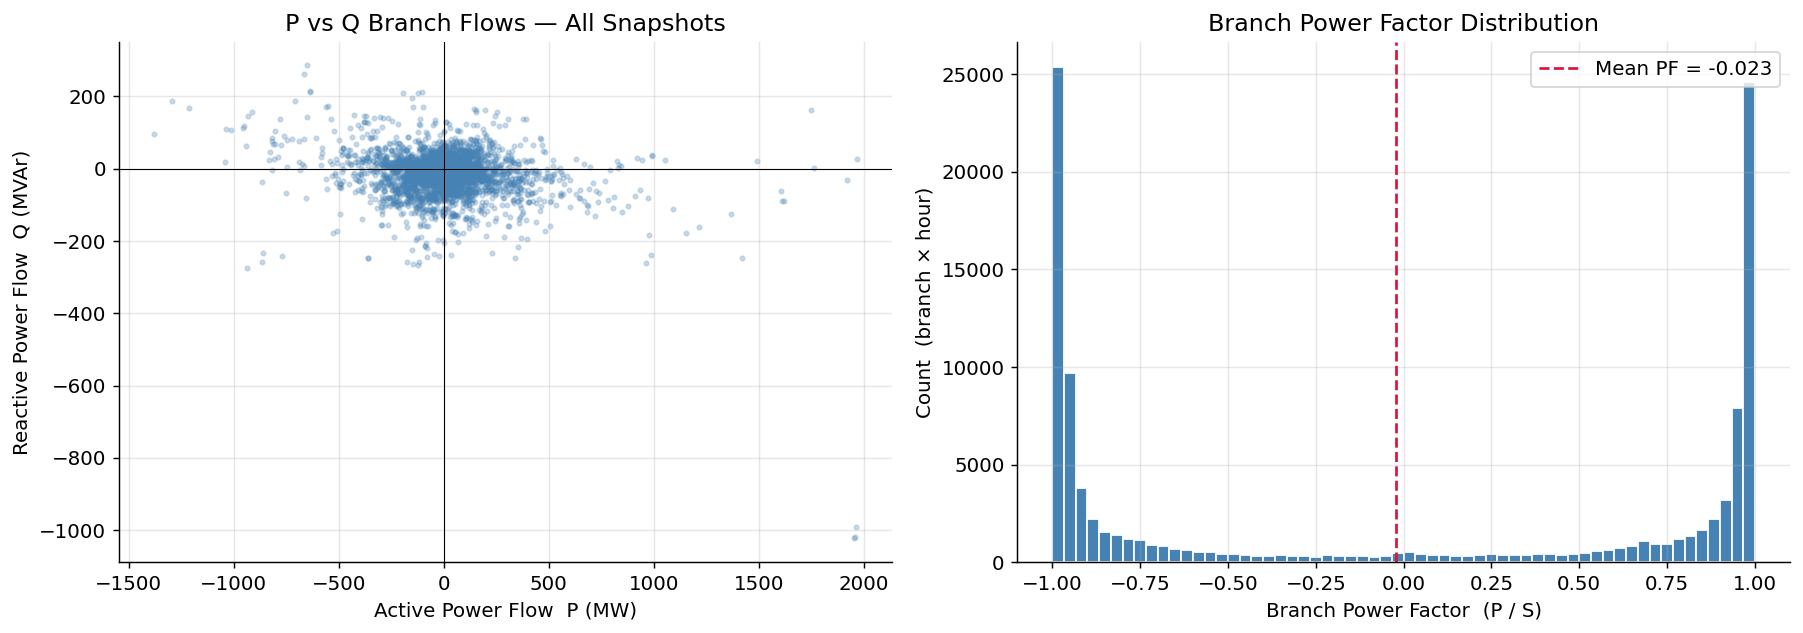

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: P vs Q scatter for all branch flows (sampled for speed)
sample = (branch_df.sample(min(8000, len(branch_df)), random_state=42)
          if len(branch_df) > 8000 else branch_df)
axes[0].scatter(sample['flow_mw'], sample['flow_mvar'],
                alpha=0.25, s=6, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].axvline(0, color='black', linewidth=0.6)
axes[0].set_xlabel('Active Power Flow  P (MW)')
axes[0].set_ylabel('Reactive Power Flow  Q (MVAr)')
axes[0].set_title('P vs Q Branch Flows — All Snapshots')

# Right: branch power factor distribution
branch_df['S_mva'] = np.hypot(branch_df['flow_mw'], branch_df['flow_mvar'])
active = branch_df[branch_df['S_mva'] > 1.0].copy()
active['pf'] = active['flow_mw'] / active['S_mva']
axes[1].hist(active['pf'], bins=60, color='steelblue', edgecolor='white')
mean_pf = active['pf'].mean()
axes[1].axvline(mean_pf, color='crimson', linestyle='--',
                label=f'Mean PF = {mean_pf:.3f}')
axes[1].set_xlabel('Branch Power Factor  (P / S)')
axes[1].set_ylabel('Count  (branch × hour)')
axes[1].set_title('Branch Power Factor Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'reactive_flows.png', bbox_inches='tight')
plt.show()

## Marginal Cost by Fuel

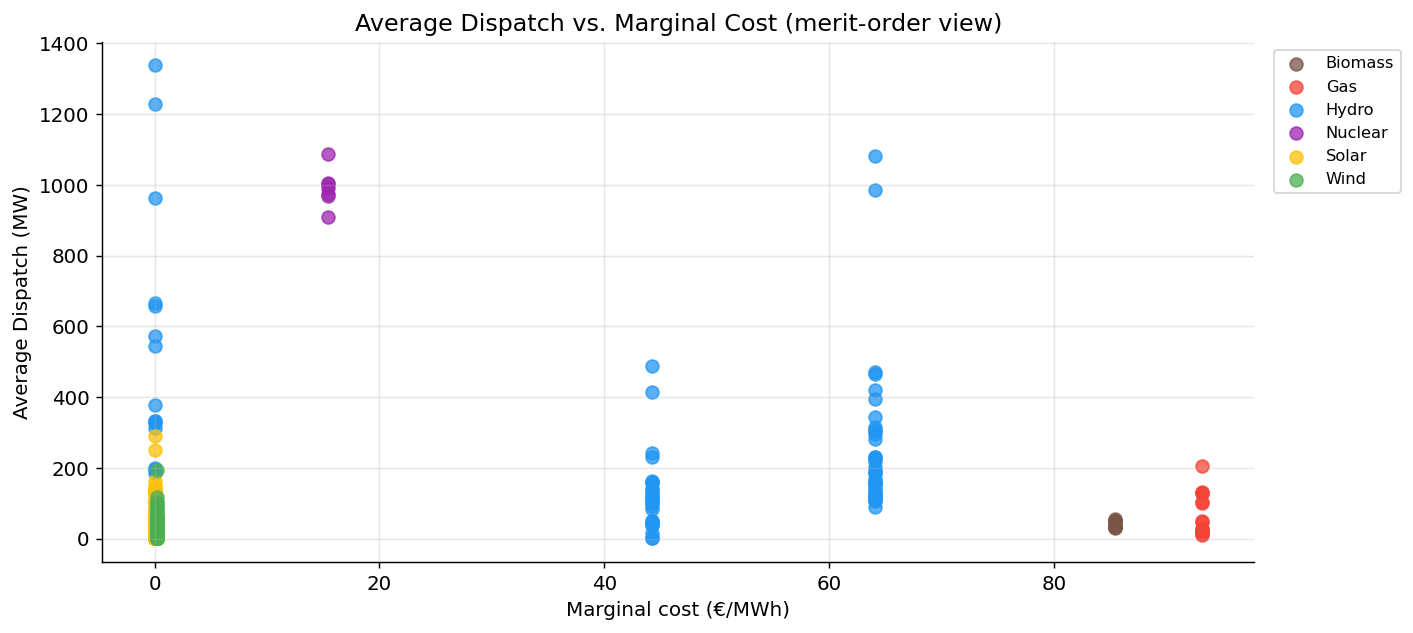

In [51]:
# Average dispatch per generator across all hours and both days
avg_dispatched = (gen_df[gen_df['dispatch_mw'] > 0.5]
                  .groupby(['unit_name', 'fuel', 'cost_eur_per_mwh'])
                  ['dispatch_mw'].mean()
                  .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
for fuel, grp in avg_dispatched.groupby('fuel'):
    ax.scatter(grp['cost_eur_per_mwh'], grp['dispatch_mw'],
               color=FUEL_COLORS.get(fuel, '#90A4AE'),
               alpha=0.75, s=50, label=fuel)

ax.set_xlabel('Marginal cost (€/MWh)')
ax.set_ylabel('Average Dispatch (MW)')
ax.set_title('Average Dispatch vs. Marginal Cost (merit-order view)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / 'merit_order.png', bbox_inches='tight')
plt.show()

In [52]:
"""
Plot an interactive power flow map using folium.

This function visualizes the power grid by plotting buses and transmission lines on an interactive map.
It displays line utilization, power flows, and optionally generation and load at each bus. The map is
color-coded to show line utilization and allows for interactive exploration of the network.

Parameters
----------
unit_generation_total : pandas.DataFrame, optional
    DataFrame with columns ['unit_id', 'actual_gen_mwh'] representing generation per unit.
flows_out : pandas.DataFrame, optional
    DataFrame with columns for each line (prefixed with 'L') and rows for each hour, representing power flows.
bus_demand : pandas.DataFrame, optional
    DataFrame with demand per bus, can be time series or single snapshot.
plot_load : bool, default False
    Whether to plot load at each bus.
plot_generation : bool, default False
    Whether to plot generation at each bus.
min_utilization_pct : float, default 0.0
    Minimum line utilization percentage to display.
hour : int, optional
    Hour index to plot (if time series data is provided).
max_capacity_pct : float, default 100
    Maximum percentage of line capacity to use for scaling.
save_path : str, default 'power_flow_map.html'
    Path to save the generated HTML map.
save : bool, default False
    Whether to save the map to file.
cos_phi : float, default 1
    Power factor for capacity calculation.

Returns
-------
None
    Opens the generated map in a web browser and optionally saves it to an HTML file.
"""

import pandas as pd
import numpy as np
import folium
from folium import Popup
from branca.colormap import linear, StepColormap
import webbrowser
import os

def plot_power_flow_interactive(unit_generation_total=None, flows_out=None, bus_demand=None,
                                plot_load=False, plot_generation=False,
                                min_utilization_pct=0.0, hour=None,
                                max_capacity_pct=100, save_path='power_flow_map.html', save=False, cos_phi=1,
                                pu_flag=0, base_power_mw=100):

    # Load input data
    buses = pd.read_csv('input_data/Bus_Data.csv')
    lines = pd.read_csv('input_data/lines_merged.csv')
    loads = pd.read_csv('input_data/load.csv')
    generation = pd.read_csv('input_data/generation.csv')

    # Normalize coordinates in Bus_Data
    if 'Longitude' in buses.columns and 'Latitude' in buses.columns:
        buses.rename(columns={'Longitude': 'x', 'Latitude': 'y'}, inplace=True)
    buses['coord_key'] = list(zip(buses['x'], buses['y']))
    coord_groups = buses.groupby('coord_key')['bus_id'].apply(list)

    # Merge generation if required
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        unit_generation_total_grouped = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum()

        gen_dict = {}
        for group in coord_groups:
            representative = group[0]
            gen_dict[representative] = sum(unit_generation_total_grouped.get(bus, 0) for bus in group)

        buses['actual_gen_mwh'] = buses['bus_id'].map(gen_dict).fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if required
    if plot_load and bus_demand is not None:
        if 'Timestep' in bus_demand.columns:
            # Full DemandOUT DataFrame
            if hour is not None and 0 <= hour < 24:
                demand_row = bus_demand.iloc[hour].drop('Timestep')
            else:
                demand_row = bus_demand.drop(columns='Timestep').mean()
        else:
            # Already a pre-processed single-hour DataFrame
            demand_row = bus_demand.set_index('bus_id')['demand']

        demand_dict = {}
        for group in coord_groups:
            representative = group[0]
            demand_dict[representative] = sum(demand_row.get(bus, 0) for bus in group)

        buses['demand'] = buses['bus_id'].map(demand_dict).fillna(0)
    else:
        buses['demand'] = 0

    # Compute net injection
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Prepare flow data
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # Select hour or average
    if hour is not None:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Compute adjusted capacity
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * 
        lines_filtered['Imax'] * 
        np.sqrt(3) * 
        # lines_filtered['circuits'] * 
        cos_phi)

    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    lines_filtered['utilization_pct'] = 100 * lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color map
    colormap = StepColormap(
        colors=list(linear.RdYlGn_11.colors)[::-1],
        index=[0,10,20,30,40,50,60,70,80,90,100],
        vmin=0,
        vmax=100,
        caption='Line Utilization (%)'
    )

    # Create base folium map centered around average bus location
    center_lat = buses['y'].mean()
    center_lon = buses['x'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='cartodb positron')

    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    # Add lines
    for _, row in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == row['bus0']].iloc[0]
        bus1 = buses[buses['bus_id'] == row['bus1']].iloc[0]

        coords = [(bus0['y'], bus0['x']), (bus1['y'], bus1['x'])]
        utilization = min(100, row['utilization_pct'])
        line_color = colormap(utilization)
        line_weight = min_width + (max_width - min_width) * ((row['flow_mw'] - flow_min) / (flow_max - flow_min))

        popup_content = f"""<b>Line ID:</b> {row['line_id']}<br>
                            <b>Flow:</b> {row['flow_mw']:.1f} MW<br>
                            <b>Capacity:</b> {row['adjusted_capacity']:.1f} MW<br>
                            <b>Utilization:</b> {utilization:.1f}%"""

        folium.PolyLine(locations=coords,
                        color=line_color,
                        weight=line_weight*1.5,
                        popup=Popup(popup_content, max_width=300)).add_to(m)

    # Add buses
    injection_threshold = 1e-2
    max_injection = buses['injection_mwh'].abs().max()

    for _, row in buses.iterrows():
        injection = row['injection_mwh']
        if abs(injection) < injection_threshold or max_injection == 0:
            size = 1
            color = 'dimgray'
            weight = 1.3
            popup_text = f"Bus ID: {row['bus_id']}<br>Injection: {injection:.4f} MWh"
        else:
            size = 3 + 20 * abs(injection) / max_injection
            color = 'blue' if injection >= 0 else 'orange'
            weight = 2
            popup_text = f"Bus ID: {row['bus_id']}<br>Injection: {injection:.1f} MWh"

        folium.CircleMarker(
            location=[row['y'], row['x']],
            radius=size,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=popup_text,
            weight=weight
        ).add_to(m)

    # Add legend
    colormap.caption = 'Line Utilization (%)'
    m.add_child(colormap)

    if not save:
        save_path = 'power_flow_map.html'

    m.save(save_path)
    webbrowser.open('file://' + os.path.realpath(save_path))
    print(f"Interactive map saved to: {save_path}")


In [53]:
def plot_power_flow(unit_generation_total=None, flows_out=None, bus_demand=None,
                    plot_high=True, plot_medium=True, plot_low=True,
                    plot_load=False, plot_generation=False,
                    min_utilization_pct=0.0, hour=0, save=False,
                    max_capacity_pct=100, cos_phi = 1, pu_flag=0, base_power_mw=100):
    buses = pd.read_csv('input_data/Bus_Data.csv')
    lines = pd.read_csv('input_data/lines_merged_all_voltages.csv')
    loads = pd.read_csv('input_data/load.csv')
    generation = pd.read_csv('input_data/generation.csv')

    voltage_levels = {
        '380 kV': 380,
        '220 kV': 200,
        '130 kV': 130
    }

    entsoe_voltage_colors = {
        '380 kV': 'tab:blue',
        '220 kV': 'tab:orange',
        'low': 'tab:green',
        'outside': 'tab:purple'
    }

    # Map actual generation to bus ids if generation plotting is requested
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if load plotting is requested
    if plot_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0
        print("No load data provided, using zero demand for all buses.")

    # Calculate net injection: generation - demand
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Process flows
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    if hour != -1:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}. Must be between 0 and {flows_out_filtered.shape[0]-1}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Calculate thermal capacity
    # Calculate thermal capacity
    lines_filtered['thermal_capacity'] = (
    lines_filtered['voltage'] * 
    lines_filtered['Imax'] * 
    np.sqrt(3) * 
    # lines_filtered['circuits'] *      # Commented since the circuits nimbers have been taken into account in the Imax of the lines_merged_all_voltages.csv file
    cos_phi)
    
    # Apply max usable capacity percentage (e.g., N-1 reserve)
    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    

    # Compute utilization based on adjusted capacity
    lines_filtered['utilization_pct'] = (lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']) * 100

    # Filter by min utilization percentage
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color gradient based on utilization
    norm = mcolors.Normalize(vmin=0, vmax=100)
    cmap = plt.get_cmap('RdYlGn_r')

    fig, ax = plt.subplots(figsize=(20, 30), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.coastlines(resolution='10m', color='gray', linewidth=0.01)
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())


    # Normalize linewidths
    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    for _, line in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == line['bus0']]
        bus1 = buses[buses['bus_id'] == line['bus1']]

        flow_color = cmap(norm(line['utilization_pct']+0.02))  # +0.01 to avoid zero color
        linestyle = '-' if line['dc'] == 'f' else '--'
        linewidth = min_width + (max_width - min_width) * ((line['flow_mw']) / (flow_max))

        ax.plot([bus0["x"].values[0], bus1["x"].values[0]],
                [bus0["y"].values[0], bus1["y"].values[0]],
                color=flow_color, linewidth=linewidth, linestyle=linestyle,
                transform=ccrs.PlateCarree())

    max_injection = buses['injection_mwh'].abs().max()
    buses['size'] = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
    buses['color'] = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

    ax.scatter(buses.x, buses.y, s=buses['size'], color=buses['color'], edgecolor="black", alpha=0.6,
               transform=ccrs.PlateCarree(), zorder=5)

    legend_elements = [
        Line2D([0], [0], color=cmap(norm(0)), lw=4, label='0% Utilization'),
        Line2D([0], [0], color=cmap(norm(50)), lw=4, label='50% Utilization'),
        Line2D([0], [0], color=cmap(norm(100)), lw=4, label='100% Utilization'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5, label='High Flow (thick line)')
    ]

    ax.legend(handles=legend_elements, loc="lower right", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=20)

    if save:
        filename = f'plotting/created_figures/power_flow_hour_{hour}.pdf' if hour is not None else 'power_flow.pdf'
        plt.savefig(filename, format='pdf')

    plt.show()

In [54]:
def plot_line_overuse_hours(unit_generation_total, flows_out, bus_demand=None,
                             show_generation=False, show_load=False,
                             min_utilization_pct=0, save=False, upper_limit=8, cos_phi=1,
                             fig_size=(20, 30), ANNOTATION=False,
                             show_zoom=False,
                             shade_spain_split=True,
                             color_NE="#EDF5F1", color_SW="#F0E4EF",
                             fill_alpha=0.28,
                             pu_flag=0, base_power_mw=100):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader as shpreader
    from shapely.geometry import LineString
    from shapely.ops import split, unary_union
    from shapely.geometry import LineString, MultiLineString, JOIN_STYLE

    
    # === Load inputs ===
    buses = pd.read_csv('input_data/Bus_Data.csv')
    lines = pd.read_csv('input_data/lines_merged.csv')

    # === Optional generation overlay ===
    if show_generation and unit_generation_total is not None:
        unit_bus_mapping = pd.read_csv('input_data/generation.csv')[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # === Optional demand overlay ===
    if show_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0

    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # === Prepare flows: keep only line columns (start with 'L'), strip the leading 'L' ===
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')].copy()
    flows_out.columns = flows_out.columns.str[1:]  # drop leading 'L' to match line_id
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    # === Align with available lines ===
    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    if not common_lines:
        print("No overlapping lines between flows_out and network definition.")
        return
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # === Thermal capacity (3*V*Imax*sqrt(3)*cos_phi for 3-phase) ===
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * lines_filtered['Imax'] * np.sqrt(3) * cos_phi
    )

    # Avoid divide-by-zero if any capacity is zero or missing
    cap = lines_filtered.set_index('line_id')['thermal_capacity'].replace(0, np.nan)
    utilization_pct = 100 * flows_out_filtered.abs().div(cap)

    # === Count overuse hours and cap at upper_limit ===
    overuse_hours = (utilization_pct > min_utilization_pct).sum()
    lines_filtered['overuse_hours'] = lines_filtered['line_id'].map(overuse_hours).fillna(0).astype(int)
    lines_filtered['capped_overuse'] = lines_filtered['overuse_hours'].clip(upper=upper_limit)

    # Average absolute flow (for linewidth scaling)
    avg_flow = flows_out_filtered.abs().mean()
    lines_filtered['avg_flow'] = lines_filtered['line_id'].map(avg_flow).fillna(0)

    # === Palette: Blue → Cyan → Green → Yellow → Orange → Red
    color_list = [
        '#c5cae9', '#bbdefb', '#4db6ac', '#81c784',
        '#9e9d24', '#f9a825', '#ef6c00', '#b71c1c'
    ]
    cmap = LinearSegmentedColormap.from_list('blue2red8', color_list, N=256)
    zero_color = '#d0d0d0'
    norm = mcolors.Normalize(vmin=1, vmax=upper_limit)

    # === Figure / main map ===
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='gray', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())
    
    
    
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # === Shade Spain NE vs SW, split by a line through 4 buses ===
    if shade_spain_split:
        # 1) Spain geometry, keep only the largest polygon (mainland)
        shpfile = shpreader.natural_earth(resolution="10m", category="cultural",
                                        name="admin_0_countries")
        recs = shpreader.Reader(shpfile).records()
        spain_parts = [r.geometry for r in recs if r.attributes.get("ADM0_A3") == "ESP"]
        if spain_parts:
            spain = unary_union(spain_parts)
            mainland = max(spain.geoms, key=lambda g: g.area) if spain.geom_type == "MultiPolygon" else spain

            # 2) dividing polyline through your buses (extended a bit)
            split_ids = ["ES00354", "ES00014", "ES00021", "ES00067"]
            pts = []
            for bid in split_ids:
                row = buses.loc[buses["bus_id"] == bid]
                if row.empty:
                    print(f"[warn] Bus {bid} not found; shading skipped.")
                    pts = []
                    break
                pts.append((float(row["x"].values[0]), float(row["y"].values[0])))

            if len(pts) >= 2:
                def extend_polyline(points, L=5.0):
                    import numpy as np
                    p = points[:]
                    dx1, dy1 = p[1][0]-p[0][0], p[1][1]-p[0][1]
                    n1 = np.hypot(dx1, dy1) or 1.0
                    p0 = (p[0][0] - L*dx1/n1, p[0][1] - L*dy1/n1)
                    dx2, dy2 = p[-1][0]-p[-2][0], p[-1][1]-p[-2][1]
                    n2 = np.hypot(dx2, dy2) or 1.0
                    pN = (p[-1][0] + L*dx2/n2, p[-1][1] + L*dy2/n2)
                    return [p0] + p[1:-1] + [pN]

                split_line = LineString(extend_polyline(pts, L=5.0))

                # 3) split mainland only
                pieces = split(mainland, split_line)
                if len(pieces.geoms) >= 2:
                    # take the two largest (the two mainland halves)
                    parts = sorted(pieces.geoms, key=lambda g: g.area, reverse=True)[:2]

                    # classify NE vs SW by centroid (bias latitude strongly)
                    import numpy as np
                    scores = [2.5*g.representative_point().y + 0.3*g.representative_point().x for g in parts]
                    ne_idx = int(np.argmax(scores))
                    ne_poly, sw_poly = parts[ne_idx], parts[1-ne_idx]

                    ax.add_geometries([ne_poly], crs=ccrs.PlateCarree(),
                                    facecolor=color_NE, edgecolor="none", alpha=fill_alpha, zorder=0)
                    ax.add_geometries([sw_poly], crs=ccrs.PlateCarree(),
                                    facecolor=color_SW, edgecolor="none", alpha=fill_alpha, zorder=0)

                    # --- parameters you can tweak ---
                    border_offset_deg = 0.02      # lateral offset (degrees). ~6–8 km in Spain; tweak as needed
                    dash_pattern = (3, 1)         # dash length, gap (points)
                    ne_line_color = "#54735F"     # green for NE
                    sw_line_color = "#A65B8C"     # red for SW
                    line_width = 2.0

                    # Base dividing polyline (use your bus order, not the extended one)
                    base_ls = LineString(pts)

                    # Parallel offsets on both sides
                    left_geom  = base_ls.parallel_offset(border_offset_deg,  side="left",
                                                        join_style=JOIN_STYLE.round)
                    right_geom = base_ls.parallel_offset(border_offset_deg,  side="right",
                                                        join_style=JOIN_STYLE.round)

                    def largest_linestring(g):
                        if isinstance(g, LineString):
                            return g
                        if isinstance(g, MultiLineString) and len(g.geoms):
                            return max(g.geoms, key=lambda ls: ls.length)
                        return None

                    left_ls  = largest_linestring(left_geom)
                    right_ls = largest_linestring(right_geom)

                    if left_ls is not None and right_ls is not None:
                        # Decide which offset is on the NE vs SW side using a midpoint test
                        mid_left  = left_ls.interpolate(0.5, normalized=True)
                        mid_right = right_ls.interpolate(0.5, normalized=True)

                        # one of these should fall inside the NE piece
                        left_is_ne  = ne_poly.contains(mid_left)
                        right_is_ne = ne_poly.contains(mid_right)

                        if left_is_ne and not right_is_ne:
                            ne_ls, sw_ls = left_ls, right_ls
                        elif right_is_ne and not left_is_ne:
                            ne_ls, sw_ls = right_ls, left_ls
                        else:
                            # Fallback: pick by which midpoint is closer to the NE part
                            dL = ne_poly.exterior.distance(mid_left)
                            dR = ne_poly.exterior.distance(mid_right)
                            ne_ls, sw_ls = (left_ls, right_ls) if dL <= dR else (right_ls, left_ls)

                        # Plot NE (green) and SW (red) dashed offsets
                        for ls, color in [(ne_ls, ne_line_color), (sw_ls, sw_line_color)]:
                            x, y = ls.xy
                            ax.plot(x, y,
                                    color=color, linewidth=line_width,
                                    linestyle=(0, dash_pattern),
                                    transform=ccrs.PlateCarree(), zorder=7)
                    else:
                        print("[warn] Could not form parallel offsets for double border; keeping single divider.")
                        # optional: fall back to the single dashed center line
                        ax.plot([p[0] for p in pts], [p[1] for p in pts],
                                transform=ccrs.PlateCarree(), color="k",
                                linestyle="--", linewidth=1.6, zorder=7)
                else:
                    print("[warn] Split returned <2 parts; shading skipped.")
        else:
            print("[warn] Spain geometry not found; shading skipped.")

    # Line width scales with avg flow across ALL lines (since we plot them all)
    min_width, max_width = 0.5, 5
    flow_min = lines_filtered['avg_flow'].min()
    flow_max = lines_filtered['avg_flow'].max()

    # --- helper to draw the network on any GeoAxes ---
    def draw_network_on(ax_like):
        # lines
        for _, line in lines_filtered.iterrows():
            bus0 = buses[buses['bus_id'] == line['bus0']]
            bus1 = buses[buses['bus_id'] == line['bus1']]
            if bus0.empty or bus1.empty:
                continue

            color = zero_color if line['overuse_hours'] == 0 else cmap(norm(line['capped_overuse']))

            if flow_max == flow_min:
                linewidth = min_width
            else:
                linewidth = min_width + (max_width - min_width) * (
                    (line['avg_flow'] - flow_min) / (flow_max - flow_min)
                )

            linestyle = '-' if line.get('dc', 'f') == 'f' else '--'

            x0, y0 = bus0["x"].values[0], bus0["y"].values[0]
            x1, y1 = bus1["x"].values[0], bus1["y"].values[0]

            ax_like.plot([x0, x1], [y0, y1],
                         color=color, linewidth=linewidth, linestyle=linestyle,
                         transform=ccrs.PlateCarree())

            # annotation
            if (line['overuse_hours'] >= 1) and ANNOTATION:
                xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
                dx, dy = (y1 - y0), -(x1 - x0)
                L = np.hypot(dx, dy)
                if L > 0:
                    dx, dy = (dx / L) * 0.15, (dy / L) * 0.15
                else:
                    dx = dy = 0.0
                ax_like.text(xm + dx, ym + dy,
                             f"{int(line['overuse_hours'])}",
                             fontsize=14, weight='regular', color='black',
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75),
                             transform=ccrs.PlateCarree(), zorder=7)

        # buses
        max_injection = buses['injection_mwh'].abs().max()
        if max_injection == 0 or np.isnan(max_injection):
            sizes = np.full(len(buses), 2.0)
        else:
            sizes = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
        colors = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

        ax_like.scatter(buses.x, buses.y, s=sizes, color=colors, edgecolor="black",
                        alpha=0.6, linewidths=0.1, transform=ccrs.PlateCarree(), zorder=5)

    # draw on main
    draw_network_on(ax)

    # === Colorbar (only for ≥1; zero is gray and not part of the bar) ===
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40)
    cbar.set_label(f'Number of Hours Line Overused', fontsize=20)
    cbar.ax.tick_params(labelsize=16)

    # === Legend ===
    legend_elements = [
        Line2D([0], [0], color=zero_color, lw=2, label='No Congestion'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5,   label='High Flow (thick line)')
    ]
    ax.legend(handles=legend_elements, loc="lower left", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=18)

    # === Optional zoomed inset (lower-right) ===
    if show_zoom:
        # your coordinates (lat, lon) -> extent is [lon_min, lon_max, lat_min, lat_max]
        lat_max, lon_right = 40.715680, -3.326443
        lat_max2, lon_left  = 40.715680, -5.809641
        lat_min, lon_left2  = 39.622386, -5.809641
        lat_min2, lon_right2= 39.622386, -3.326443
        lon_min = min(lon_left, lon_left2)
        lon_max = max(lon_right, lon_right2)
        lat_min = min(lat_min, lat_min2)
        lat_max = max(lat_max, lat_max2)
        
        # desired margins (as fraction of the main axes, 0..1)
        right_pad  = 0.01   # gap to right edge
        bottom_pad = -0.03   # gap to bottom edge
        w, h = 0.35, 0.35   # inset size as fraction of the main axes

        # inset sized to ~35% of the axes in lower-right
        axins = inset_axes(
            ax,
            width="100%", height="100%",
            bbox_to_anchor=(1 - w - right_pad,  # left
                            bottom_pad,         # bottom
                            w, h),              # width, height
            bbox_transform=ax.transAxes,
            borderpad=0,                        # we control gaps manually
            axes_class=GeoAxes,
            axes_kwargs=dict(map_projection=ccrs.PlateCarree())
        )
        
            # dashed black border for inset
        for spine in axins.spines.values():
            spine.set_edgecolor('black')
            spine.set_linestyle('-.')
            spine.set_linewidth(2.5)
        
        # basic features on inset
        axins.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
        axins.add_feature(cfeature.COASTLINE, linewidth=0.5)
        axins.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.4)
        axins.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        # draw network inside inset
        draw_network_on(axins)

        # draw a dashed rectangle on main map to indicate zoomed area
        rect = Rectangle(
            (lon_min, lat_min),
            width=(lon_max - lon_min), height=(lat_max - lat_min),
            linewidth=1.5, edgecolor='k', facecolor='none', linestyle='-.',
            transform=ccrs.PlateCarree(), zorder=10
        )
        ax.add_patch(rect)

    if save:
        plt.savefig('plotting\\created_figures\\line_overuse_spectrum.pdf', format='pdf', bbox_inches='tight', dpi=300)

    plt.show()


## Network Map — OPF Results

Interactive folium map of the Spain transmission network, coloured by branch loading and bus generation fuel mix.

In [55]:
import pandas as pd
import numpy as np
import folium
from folium import Popup
from branca.colormap import StepColormap
import os
import webbrowser

# ── Load data ────────────────────────────────────────────────────────────────
buses = pd.read_csv('Data/Bus_Data.csv')          # bus_id, voltage, y (lat), x (lon)
buses.index = range(1, len(buses) + 1)            # make 1-based to match result indices

branch_df = pd.read_csv('results/branch_flows.csv')
gen_df    = pd.read_csv('results/gen_dispatch.csv')

# ── Per-bus aggregation ──────────────────────────────────────────────────────
dispatched = gen_df[gen_df['dispatch_mw'] > 0].copy()
bus_total  = dispatched.groupby('bus_i')['dispatch_mw'].sum()
# dominant fuel = fuel with the highest single-unit dispatch at each bus
dom_fuel   = (dispatched.loc[dispatched.groupby('bus_i')['dispatch_mw'].idxmax(),
                             ['bus_i', 'fuel']]
              .set_index('bus_i')['fuel'])

buses['dispatch_mw'] = bus_total.reindex(buses.index).fillna(0)
buses['dom_fuel']    = dom_fuel.reindex(buses.index).fillna('')

# ── Colour maps ──────────────────────────────────────────────────────────────
# green → yellow → red for branch loading
loading_cmap = StepColormap(
    colors=['#1a9850', '#91cf60', '#d9ef8b', '#fee08b', '#fc8d59', '#d73027'],
    index=[0, 20, 40, 60, 80, 100, 120],
    vmin=0, vmax=120,
    caption='Branch Loading (%)',
)

# same fuel colours as the rest of the notebook
FUEL_COLORS = {
    'Wind':    '#4CAF50',
    'Solar':   '#FFC107',
    'Hydro':   '#2196F3',
    'Nuclear': '#9C27B0',
    'Gas':     '#F44336',
    'Coal':    '#212121',
    'Biomass': '#795548',
    'Oil':     '#607D8B',
}

# ── Create base map ──────────────────────────────────────────────────────────
m = folium.Map(
    location=[buses['y'].mean(), buses['x'].mean()],
    zoom_start=6,
    tiles='CartoDB positron',
)

# ── Draw transmission branches ───────────────────────────────────────────────
flow_max = branch_df['flow_mw'].max() or 1.0
for _, row in branch_df.iterrows():
    b0 = buses.loc[row['from_bus']]
    b1 = buses.loc[row['to_bus']]
    loading   = min(float(row['loading_pct']), 120)
    congested = loading >= 90
    color     = loading_cmap(loading)
    weight    = 1.0 + 4.0 * (row['flow_mw'] / flow_max)
    opacity   = 0.9 if congested else 0.6

    folium.PolyLine(
        locations=[(b0['y'], b0['x']), (b1['y'], b1['x'])],
        color=color,
        weight=weight * (1.4 if congested else 1.0),
        opacity=opacity,
        tooltip=f"{row['branch_name']}: {row['loading_pct']:.0f}%",
        popup=Popup(
            f"<b>{row['branch_name']}</b><br>"
            f"Flow: <b>{row['flow_mw']:.1f} MW</b><br>"
            f"Limit: {row['limit_mw']:.1f} MW<br>"
            f"Loading: <b style='color:{'crimson' if congested else 'green'}'>"
            f"{row['loading_pct']:.1f}%</b>",
            max_width=260
        )
    ).add_to(m)

# ── Draw buses ───────────────────────────────────────────────────────────────
max_disp = buses['dispatch_mw'].max() or 1.0
for bus_idx, brow in buses.iterrows():
    d = brow['dispatch_mw']
    if d > 1:
        radius   = 3 + 14 * (d / max_disp)
        fill_col = FUEL_COLORS.get(brow['dom_fuel'], '#90A4AE')
        popup_txt = (f"<b>{brow['bus_id']}</b> ({brow['voltage']} kV)<br>"
                     f"Dispatch: <b>{d:.1f} MW</b><br>"
                     f"Dominant fuel: {brow['dom_fuel']}")
    else:
        radius    = 2
        fill_col  = '#bdbdbd'
        popup_txt = f"<b>{brow['bus_id']}</b> ({brow['voltage']} kV)<br>No generation"

    folium.CircleMarker(
        location=[brow['y'], brow['x']],
        radius=radius,
        color='#444',
        fill=True,
        fill_color=fill_col,
        fill_opacity=0.8,
        weight=0.6,
        tooltip=brow['bus_id'],
        popup=Popup(popup_txt, max_width=220)
    ).add_to(m)

# ── Fuel legend (fixed HTML overlay) ────────────────────────────────────────
legend_items = ''.join(
    f'<span style="background:{c};width:13px;height:13px;display:inline-block;'
    f'border-radius:50%;margin-right:6px;vertical-align:middle"></span>{f}<br>'
    for f, c in FUEL_COLORS.items()
)
legend_html = f"""
<div style="position:fixed;bottom:60px;left:50px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            border:1px solid #ccc;font-size:12px;line-height:2.0">
  <b>Dominant Fuel at Bus</b><br>{legend_items}
  <span style="background:#bdbdbd;width:13px;height:13px;display:inline-block;
    border-radius:50%;margin-right:6px;vertical-align:middle"></span>No generation
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m.add_child(loading_cmap)
output_path = os.path.abspath('results/power_flow_map.html')
m.save(output_path)
webbrowser.open(f'file://{output_path}')
print("Map saved → results/power_flow_map.html")

Map saved → results/power_flow_map.html


## Bus Power Factor & Reactive Power Map

Cartopy map of the Spain transmission network where each bus circle is:
- **Coloured** by power factor (RdYlGn: red = low PF, green = PF close to 1)
- **Sized** by the magnitude of reactive power injected or absorbed at that bus (MVAr)
- **Edge colour**: green = Q injecting (generators supplying reactive power), red = Q absorbing

Lines are coloured by average loading (%). Set `DATE`/`HOUR` for a specific snapshot, or leave `None` to average all snapshots. Set `SAVE=True` to export to `results/pf_reactive_map.png`.

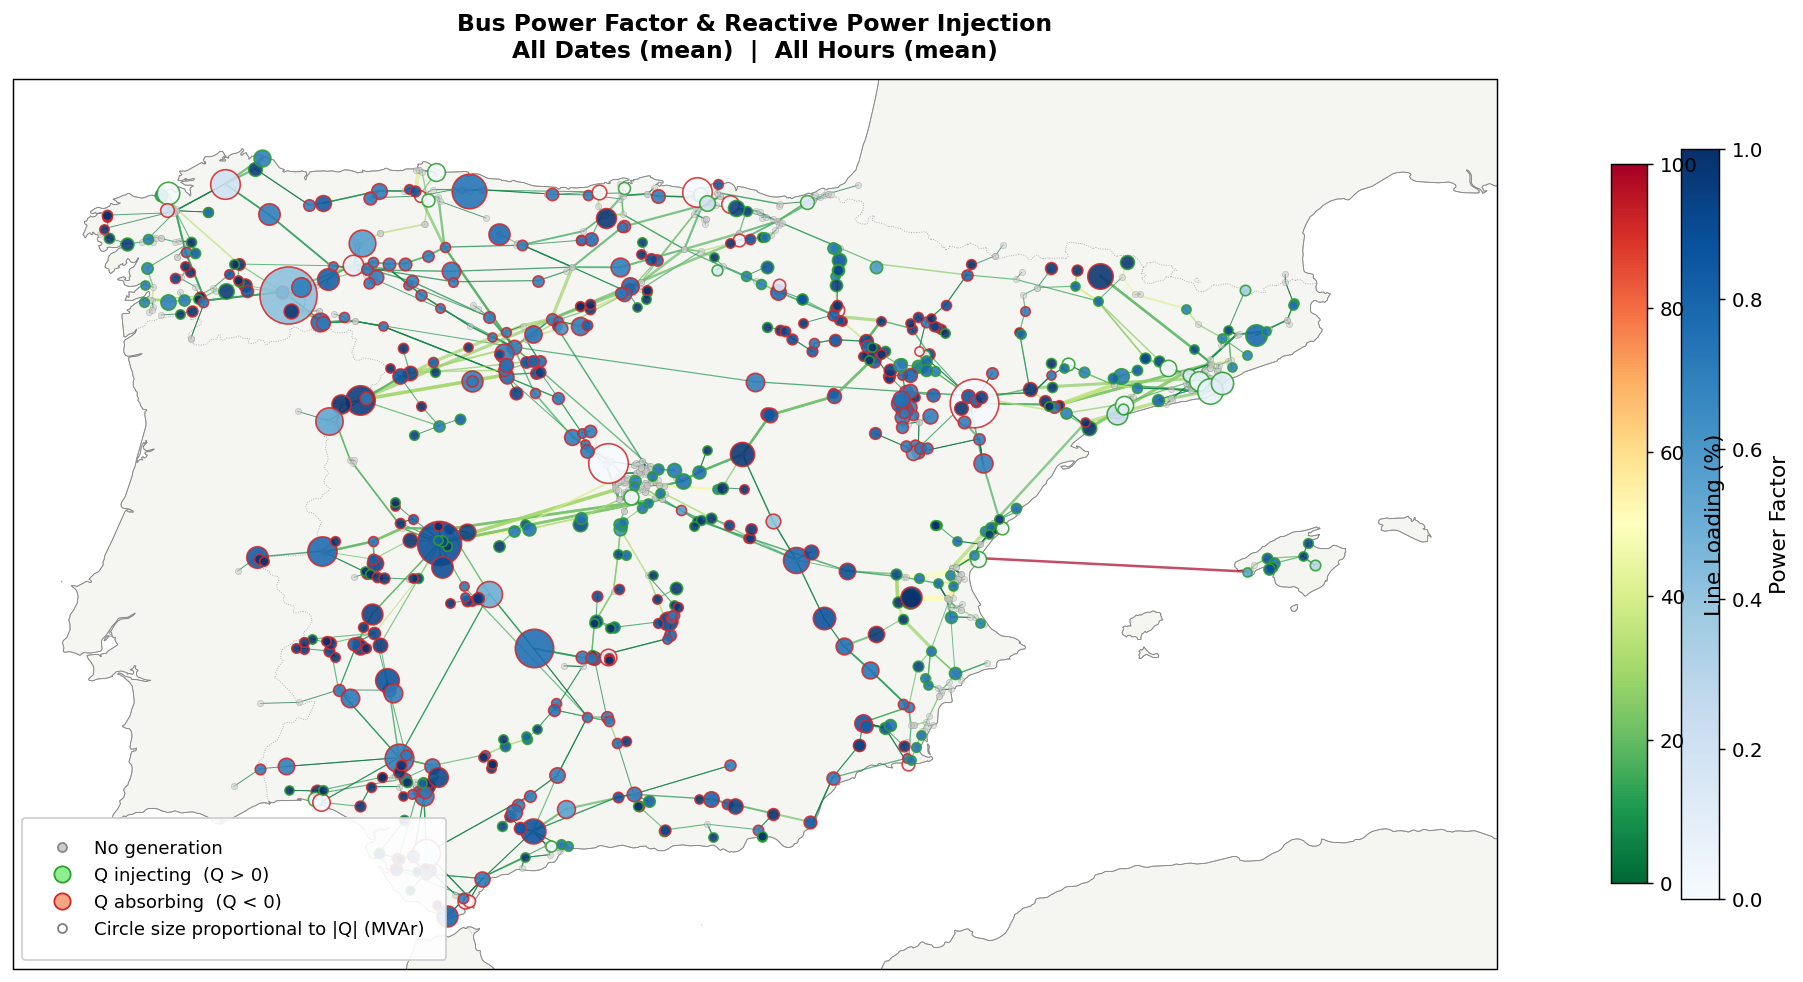

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -- Configuration --------------------------------------------------------------
DATE  = None          # e.g. '2024-07-08'  |  None = mean over all dates
HOUR  = None          # e.g. 12            |  None = mean over all hours
SAVE  = False

RESULTS = Path('results')

# -- Load data (same paths as the rest of this notebook) -----------------------
buses     = pd.read_csv('Data/Bus_Data.csv')
gen_df    = pd.read_csv(RESULTS / 'gen_dispatch.csv')
branch_df = pd.read_csv(RESULTS / 'branch_flows.csv')

# 1-based integer index to match from_bus / to_bus in branch_flows
buses.index = range(1, len(buses) + 1)

# -- Snapshot filter ------------------------------------------------------------
gdf = gen_df.copy()
bdf = branch_df.copy()
if DATE is not None:
    gdf = gdf[gdf['date'] == DATE]
    bdf = bdf[bdf['date'] == DATE]
if HOUR is not None:
    gdf = gdf[gdf['hour'] == HOUR]
    bdf = bdf[bdf['hour'] == HOUR]

# -- Per-bus P and Q (mean over selected snapshots) -----------------------------
bus_P = gdf.groupby('bus_i')['dispatch_mw'].mean().rename('P_mw')
bus_Q = gdf.groupby('bus_i')['dispatch_mvar'].mean().rename('Q_mvar')

buses['P_mw']   = bus_P.reindex(buses.index).fillna(0.0)
buses['Q_mvar'] = bus_Q.reindex(buses.index).fillna(0.0)
buses['S_mva']  = np.sqrt(buses['P_mw']**2 + buses['Q_mvar']**2)
buses['pf']     = np.where(buses['S_mva'] > 0.1, buses['P_mw'] / buses['S_mva'], np.nan)
buses['Q_abs']  = buses['Q_mvar'].abs()

# -- Aggregate branches (mean loading over selected snapshots) ------------------
branch_agg = (bdf
              .groupby(['branch_name', 'from_bus', 'to_bus'])
              .agg(flow_mw=('flow_mw', 'mean'), loading_pct=('loading_pct', 'mean'))
              .reset_index())

# -- Figure --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 20),
                       subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_alpha(0)
ax.add_feature(cfeature.LAND,      facecolor='#f5f5f2', edgecolor='#a0a0a0', linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5,        edgecolor='#888888')
ax.add_feature(cfeature.BORDERS,   linewidth=0.5,        linestyle=':', edgecolor='#aaaaaa')
ax.set_extent([-10, 5, 35.5, 44.5], crs=ccrs.PlateCarree())

# -- Transmission lines coloured by loading (green → yellow → red) -------------
loading_norm = mcolors.Normalize(vmin=0, vmax=100)
loading_cmap = plt.get_cmap('RdYlGn_r')   # green=low load, red=high load
flow_max = branch_agg['flow_mw'].abs().max() or 1.0

for _, row in branch_agg.iterrows():
    try:
        b0 = buses.loc[int(row['from_bus'])]
        b1 = buses.loc[int(row['to_bus'])]
    except KeyError:
        continue
    loading = float(np.clip(row['loading_pct'], 0, 100))
    lw      = 0.5 + 4.5 * abs(row['flow_mw']) / flow_max
    ax.plot([b0['x'], b1['x']], [b0['y'], b1['y']],
            color=loading_cmap(loading_norm(loading)),
            linewidth=lw, alpha=0.7, zorder=2,
            transform=ccrs.PlateCarree())

# -- Buses coloured by PF (light blue → dark blue), sized by |Q| ---------------
# Deliberately different spectrum from lines to avoid confusion
pf_cmap = plt.get_cmap('Blues')   # light=low PF, dark blue=PF close to 1
pf_norm  = mcolors.Normalize(vmin=0, vmax=1)
q_max    = buses['Q_abs'].max() or 1.0
MIN_S, MAX_S = 25, 1000

for _, row in buses.iterrows():
    q   = float(row['Q_abs'])
    pf  = row['pf']
    lat = float(row['y'])
    lon = float(row['x'])

    if q < 0.1 or np.isnan(pf):
        # No generation -- small grey dot
        ax.scatter(lon, lat, s=12, color='#cccccc', edgecolor='#888888',
                   linewidth=0.3, alpha=0.55, zorder=4,
                   transform=ccrs.PlateCarree())
        continue

    size     = MIN_S + (MAX_S - MIN_S) * (q / q_max)
    face_col = pf_cmap(pf_norm(pf))
    edge_col = '#2ca02c' if row['Q_mvar'] >= 0 else '#d62728'  # green=injecting, red=absorbing

    ax.scatter(lon, lat, s=size, color=face_col, edgecolor=edge_col,
               linewidth=0.9, alpha=0.88, zorder=5,
               transform=ccrs.PlateCarree())

# -- Colorbars -----------------------------------------------------------------
sm_pf   = cm.ScalarMappable(cmap=pf_cmap,      norm=pf_norm)
sm_load = cm.ScalarMappable(cmap=loading_cmap, norm=loading_norm)
sm_pf.set_array([])
sm_load.set_array([])

cbar_pf = fig.colorbar(sm_pf, ax=ax, orientation='vertical',
                        fraction=0.022, pad=0.02, shrink=0.35)
cbar_pf.set_label('Power Factor', fontsize=12)

cbar_ld = fig.colorbar(sm_load, ax=ax, orientation='vertical',
                        fraction=0.022, pad=0.07, shrink=0.35)
cbar_ld.set_label('Line Loading (%)', fontsize=12)

# -- Legend --------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#cccccc',
           markersize=5,  markeredgecolor='#888888', label='No generation'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
           markersize=9,  markeredgecolor='#2ca02c', label='Q injecting  (Q > 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f4a582',
           markersize=9,  markeredgecolor='#d62728', label='Q absorbing  (Q < 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markersize=5,  markeredgecolor='gray',    label='Circle size proportional to |Q| (MVAr)'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=10,
          frameon=True, framealpha=0.9, borderpad=1.2)

# -- Title ---------------------------------------------------------------------
date_lbl = DATE if DATE else 'All Dates (mean)'
hour_lbl = f'Hour {HOUR}' if HOUR is not None else 'All Hours (mean)'
ax.set_title(
    f'Bus Power Factor & Reactive Power Injection\n{date_lbl}  |  {hour_lbl}',
    fontsize=13, fontweight='bold', pad=12
)

plt.tight_layout()
if SAVE:
    out = RESULTS / 'pf_reactive_map.png'
    plt.savefig(str(out), dpi=150, bbox_inches='tight')
    print(f'Saved to {out}')
plt.show()


## Hourly Generation Mix — July 8 & December 2

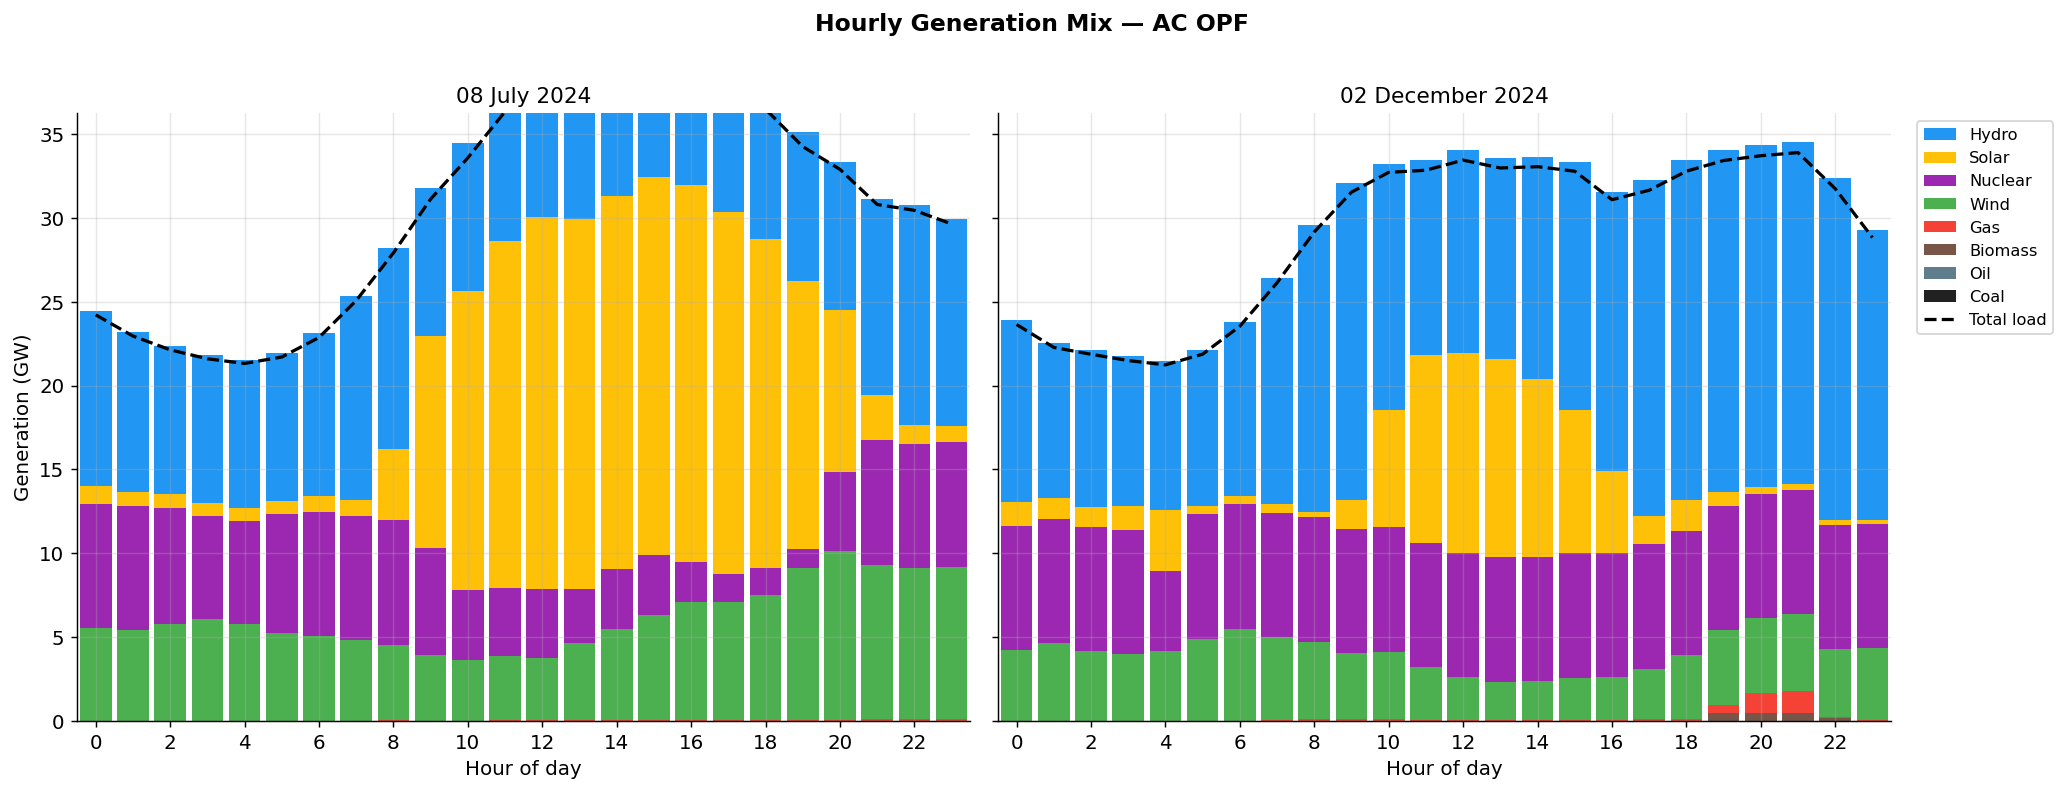

In [57]:
fuel_df    = pd.read_csv(RESULTS / 'fuel_mix.csv')
summary_df = pd.read_csv(RESULTS / 'summary.csv')

days = sorted(fuel_df['date'].unique())

plot_fuels = fuel_df[fuel_df['fuel'] != 'Slack']

fuel_order = (plot_fuels.groupby('fuel')['dispatch_mw'].mean()
              .sort_values(ascending=True).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Hourly Generation Mix — AC OPF', fontsize=13, fontweight='bold', y=1.01)

for ax, day in zip(axes, days):
    day_fuel = plot_fuels[plot_fuels['date'] == day]
    day_sum  = summary_df[summary_df['date'] == day].sort_values('hour')

    pivot = (day_fuel
             .pivot_table(index='hour', columns='fuel',
                          values='dispatch_mw', fill_value=0)
             .reindex(range(24), fill_value=0))
    pivot = pivot[[f for f in fuel_order if f in pivot.columns]]

    bottom = np.zeros(24)
    for fuel in pivot.columns:
        vals = pivot[fuel].values / 1e3
        ax.bar(range(24), vals, bottom=bottom,
               color=FUEL_COLORS.get(fuel, '#90A4AE'),
               label=fuel, width=0.85, edgecolor='none')
        bottom += vals

    load_gw = day_sum['total_load_mw'].values / 1e3
    ax.plot(day_sum['hour'], load_gw,
            'k--', linewidth=1.8, label='Total load', zorder=5)

    ax.set_title(pd.Timestamp(day).strftime('%d %B %Y'), fontsize=12)
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, bottom.max() * 1.05)

axes[0].set_ylabel('Generation (GW)')

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.02, 1),
               loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig(RESULTS / 'hourly_generation_mix.png', bbox_inches='tight')
plt.show()

## Hourly System Prices

Total system cost (€/h) and derived system price (€/MWh = cost / load) for each hour.
High prices indicate heavy reliance on the expensive slack/peaking units.

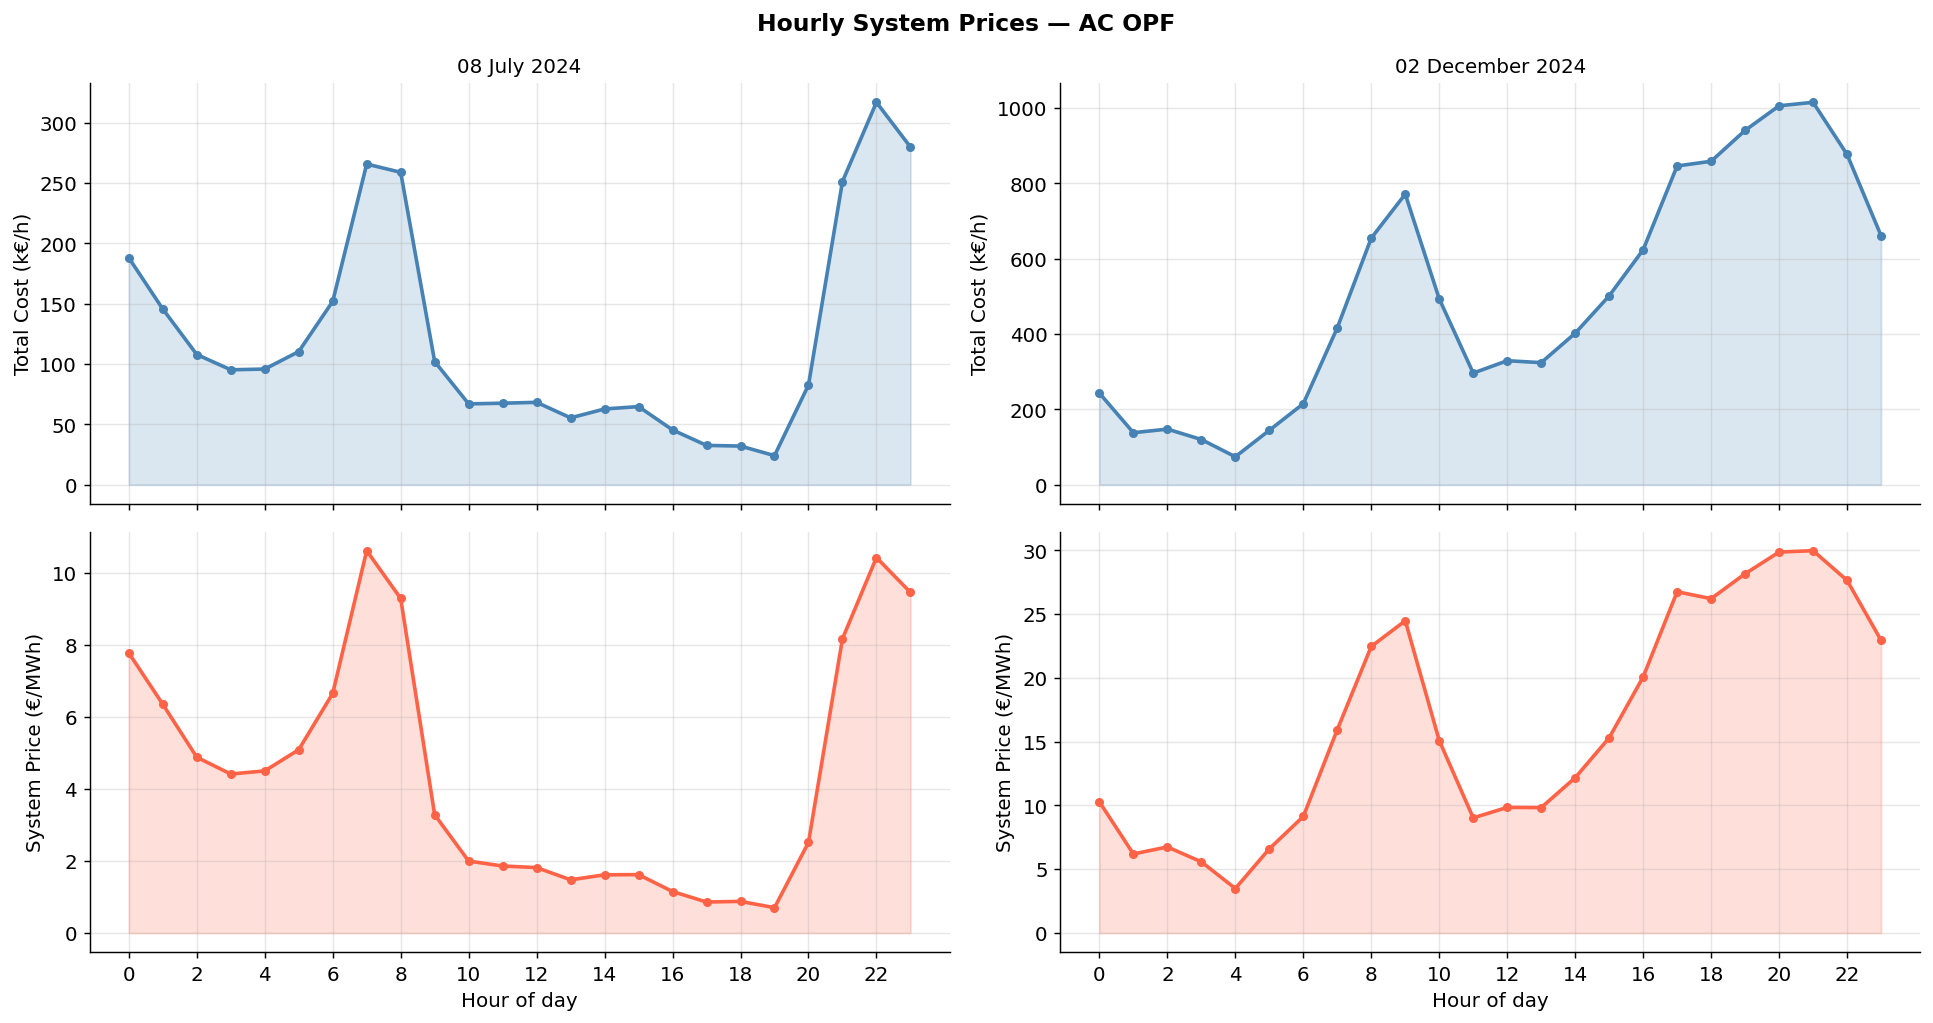

In [58]:
summary_df = pd.read_csv(RESULTS / 'summary.csv')
solved = summary_df[summary_df['status'].isin(['OPTIMAL', 'LOCALLY_SOLVED'])].copy()
solved['price_eur_mwh'] = solved['objective_eur_h'] / solved['total_load_mw']

days = sorted(solved['date'].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
fig.suptitle('Hourly System Prices — AC OPF', fontsize=13, fontweight='bold')

for col, day in enumerate(days):
    day_df = solved[solved['date'] == day].sort_values('hour')
    label  = pd.Timestamp(day).strftime('%d %B %Y')

    ax_cost  = axes[0, col]
    ax_price = axes[1, col]

    ax_cost.fill_between(day_df['hour'], day_df['objective_eur_h'] / 1e3,
                         alpha=0.2, color='steelblue')
    ax_cost.plot(day_df['hour'], day_df['objective_eur_h'] / 1e3,
                 color='steelblue', linewidth=2, marker='o', markersize=4)
    ax_cost.set_title(label, fontsize=11)
    ax_cost.set_ylabel('Total Cost (k€/h)')

    ax_price.fill_between(day_df['hour'], day_df['price_eur_mwh'],
                          alpha=0.2, color='tomato')
    ax_price.plot(day_df['hour'], day_df['price_eur_mwh'],
                  color='tomato', linewidth=2, marker='o', markersize=4)
    ax_price.set_xlabel('Hour of day')
    ax_price.set_ylabel('System Price (€/MWh)')
    ax_price.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(RESULTS / 'hourly_prices.png', bbox_inches='tight')
plt.show()

## Slack Bus Generation

The slack unit at bus ES00029 acts as an unconstrained balancing generator (cost = 1 000 × base).
Non-zero dispatch signals hours where the real generator fleet cannot meet demand — indicating
insufficient capacity or binding transmission constraints.
Red bars highlight hours where the shortfall exceeds 100 MW.

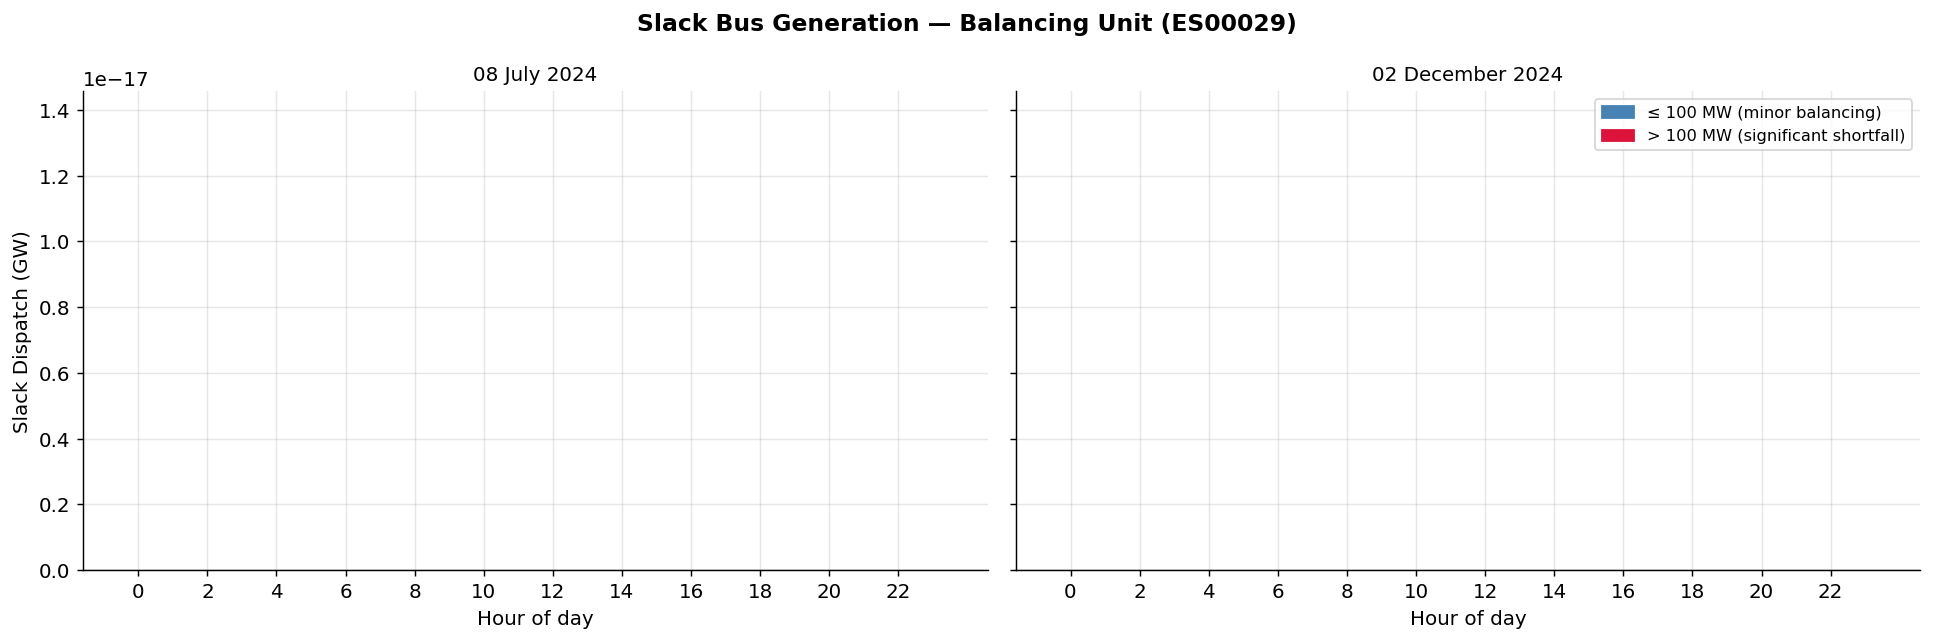

      date  peak_mw  total_mwh
2024-07-08     -0.0        0.0
2024-12-02     -0.0        0.0


In [59]:
gen_df   = pd.read_csv(RESULTS / 'gen_dispatch.csv')
slack_df = gen_df[gen_df['fuel'] == 'Slack'].copy()
days     = sorted(slack_df['date'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('Slack Bus Generation — Balancing Unit (ES00029)', fontsize=13, fontweight='bold')

for ax, day in zip(axes, days):
    day_df = slack_df[slack_df['date'] == day].sort_values('hour')
    label  = pd.Timestamp(day).strftime('%d %B %Y')
    colors = ['crimson' if v > 100 else 'steelblue' for v in day_df['dispatch_mw']]
    ax.bar(day_df['hour'], day_df['dispatch_mw'] / 1e3, color=colors, width=0.8, edgecolor='none')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(0, 24, 2))
    ax.axhline(0, color='black', linewidth=0.6)

axes[0].set_ylabel('Slack Dispatch (GW)')

from matplotlib.patches import Patch
legend_handles = [Patch(color='steelblue', label='≤ 100 MW (minor balancing)'),
                  Patch(color='crimson',   label='> 100 MW (significant shortfall)')]
axes[1].legend(handles=legend_handles, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS / 'slack_generation.png', bbox_inches='tight')
plt.show()

peak  = slack_df.groupby('date')['dispatch_mw'].max().rename('peak_mw')
total = slack_df.groupby('date')['dispatch_mw'].sum().rename('total_mwh')
print(pd.concat([peak, total], axis=1).reset_index().to_string(index=False))

## Bus Voltage Map

Geographic map of bus voltage magnitude across all solved hours.
Colour scale is centred at 1.0 pu (green); red = low voltage (< 0.95 pu), yellow/orange = above 1.0 pu.
Left panel shows the **mean** voltage; right panel shows the **worst-case minimum** at each bus.

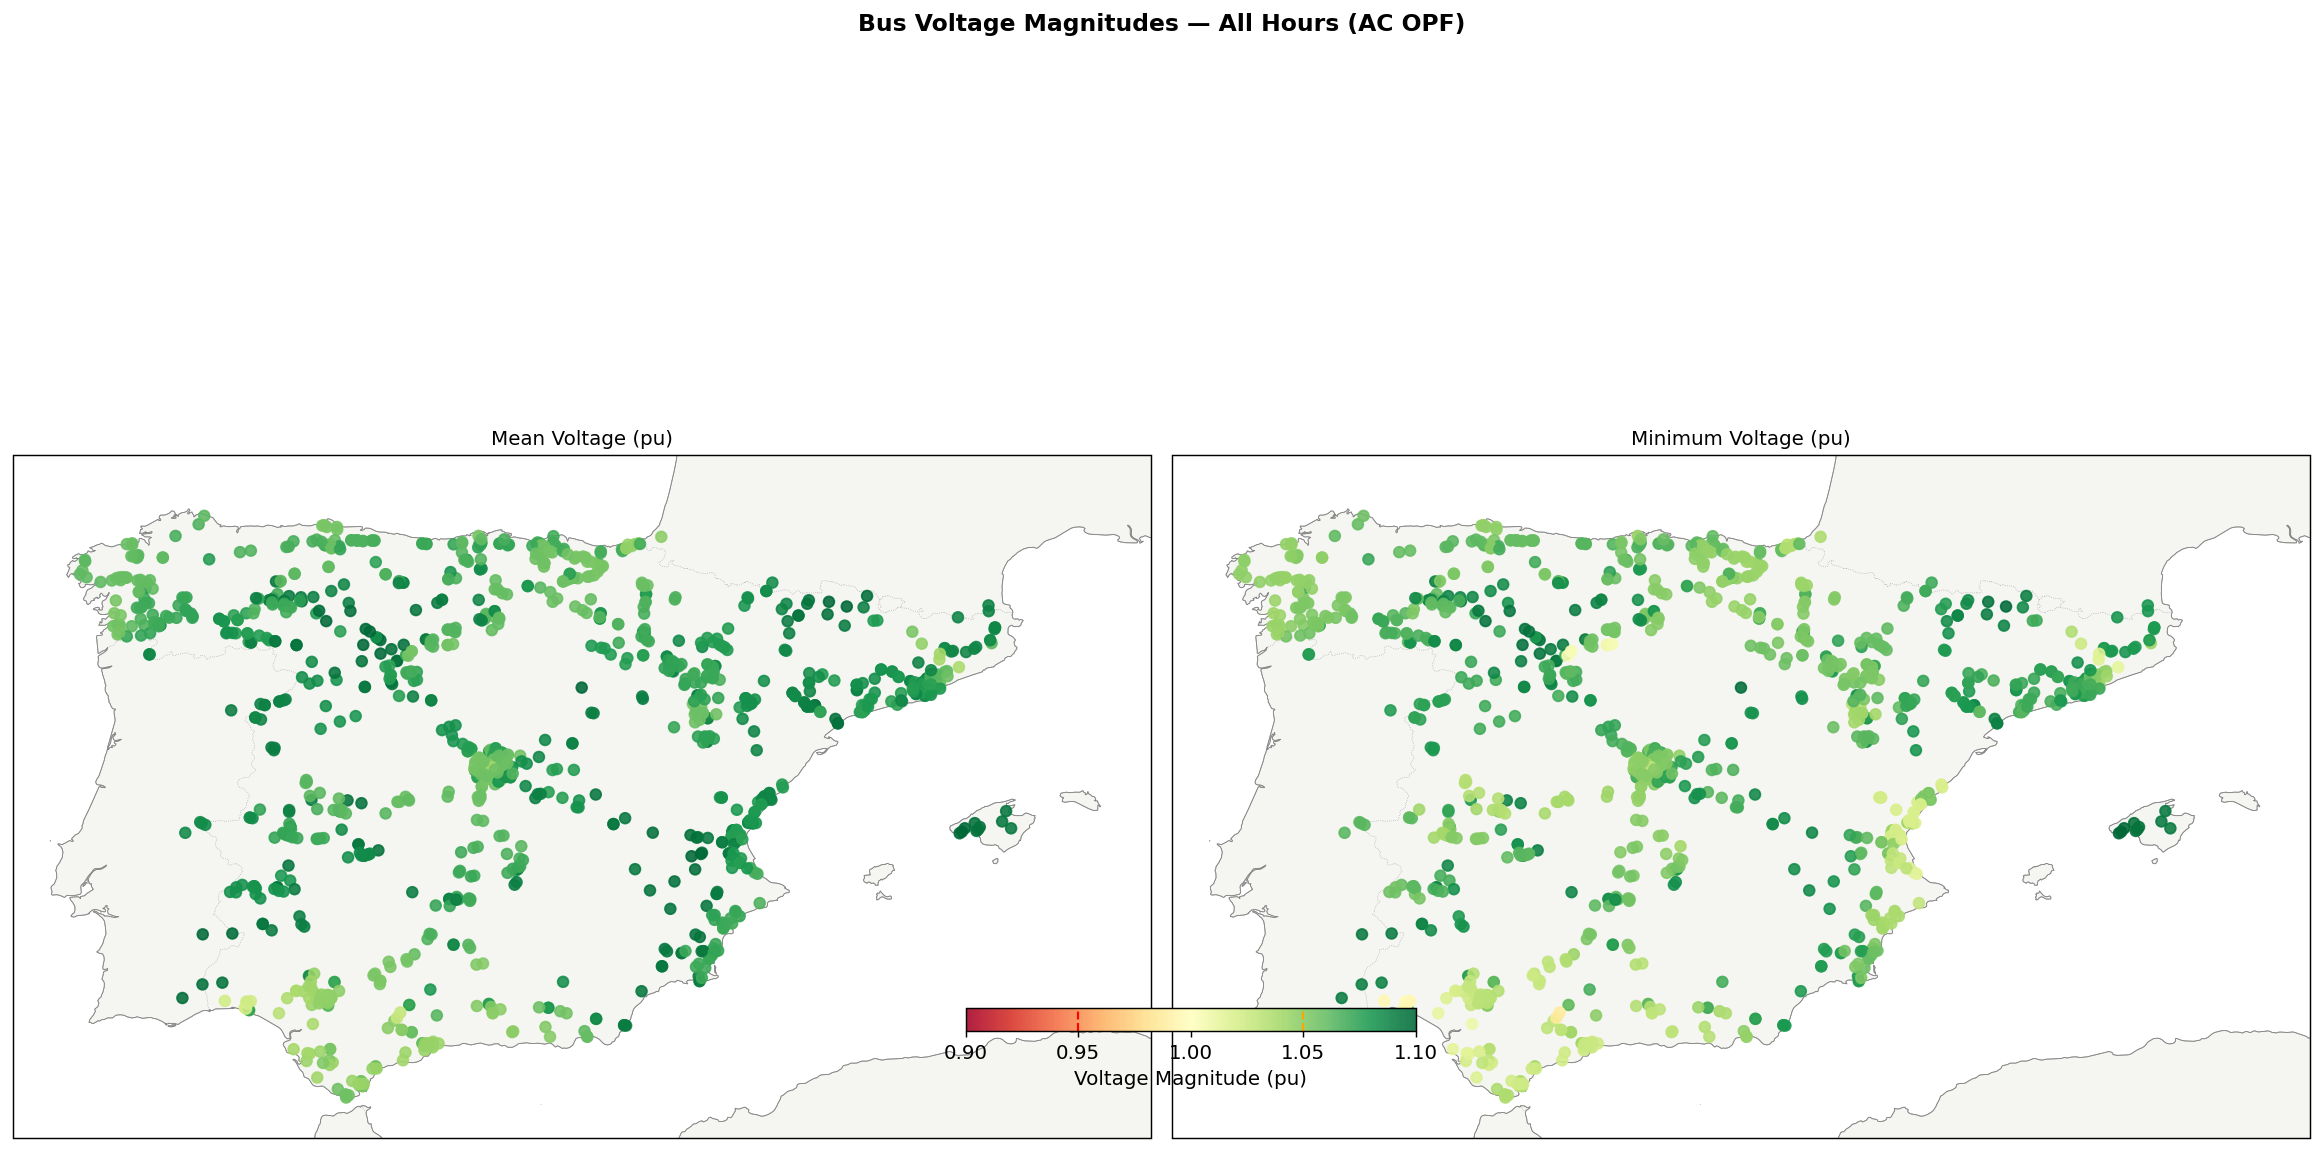

Bus-hours below 0.95 pu : 0  (0.0%)
Bus-hours above 1.05 pu : 52,501 (88.5%)


In [60]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.cm as cm

voltage_df = pd.read_csv(RESULTS / 'bus_voltages.csv')
buses_geo  = pd.read_csv('Data/Bus_Data.csv')

avg_vm = (voltage_df.groupby('bus_id')['vm_pu']
          .agg(vm_mean='mean', vm_min='min', vm_max='max')
          .reset_index())
buses_geo = buses_geo.merge(avg_vm, on='bus_id', how='left')

norm = mcolors.TwoSlopeNorm(vmin=0.90, vcenter=1.0, vmax=1.10)
cmap = plt.get_cmap('RdYlGn')

fig, axes = plt.subplots(1, 2, figsize=(18, 9),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle('Bus Voltage Magnitudes — All Hours (AC OPF)',
             fontsize=13, fontweight='bold')

titles = ['Mean Voltage (pu)', 'Minimum Voltage (pu)']
cols   = ['vm_mean', 'vm_min']

for ax, col, title in zip(axes, cols, titles):
    ax.add_feature(cfeature.LAND,      facecolor='#f5f5f2', edgecolor='#a0a0a0', linewidth=0.4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,       edgecolor='#888888')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4,       linestyle=':', edgecolor='#aaaaaa')
    ax.set_extent([-10, 5, 35.5, 44.5], crs=ccrs.PlateCarree())

    valid = buses_geo.dropna(subset=[col])
    sc = ax.scatter(valid['x'].values, valid['y'].values,
                    c=valid[col].values,
                    cmap=cmap, norm=norm,
                    s=35, alpha=0.88, zorder=5,
                    transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=11)

cbar = fig.colorbar(sc, ax=axes.tolist(), orientation='horizontal',
                    fraction=0.025, pad=0.04, shrink=0.55)
cbar.set_label('Voltage Magnitude (pu)', fontsize=11)
# mark ±5% limit on the colorbar
cbar.ax.axvline(0.95, color='red',    linestyle='--', linewidth=1.2, label='0.95 pu')
cbar.ax.axvline(1.05, color='orange', linestyle='--', linewidth=1.2, label='1.05 pu')

plt.tight_layout()
plt.savefig(RESULTS / 'bus_voltage_map.png', bbox_inches='tight', dpi=130)
plt.show()

n_low  = (voltage_df['vm_pu'] < 0.95).sum()
n_high = (voltage_df['vm_pu'] > 1.05).sum()
print(f"Bus-hours below 0.95 pu : {n_low:,}  ({100*n_low/len(voltage_df):.1f}%)")
print(f"Bus-hours above 1.05 pu : {n_high:,} ({100*n_high/len(voltage_df):.1f}%)")